In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

소속: 성균관대학교 심원목교수님연구실

이름: 박상현

직위: 박사과정1년차

# Q1

## Implementing the environment and the agents

In [2]:
class KBandit:
    def __init__(self, n_arms, reward_type='binary', stationary=True, step_size=0.1, state_noise=0.3, measurement_noise=0.3):
        self.n_arms = n_arms
        self.reward_type = reward_type
        self.stationary = stationary
        self.step_size = step_size    
        self.state_noise = state_noise    
        self.measurement_noise = measurement_noise    
        if self.reward_type == "continuous":
            self.action_values = np.random.normal(size=self.n_arms)
            self.reward_func = self._continuous_reward
        elif self.reward_type == "binary":
            self.action_values = np.random.rand(self.n_arms)
            self.reward_func = self._binary_reward
        else:
            raise ValueError("Reward type not recognized")
    
    def _binary_reward(self, action):
        # Return a binary reward with probability equal to the reward_probs for that action
        return np.random.choice([0, 1], p=[1-self.action_values[action], self.action_values[action]])
    def _continuous_reward(self, action):
        return np.random.normal(self.action_values[action], self.measurement_noise)
    def step(self, action):
        # Take an action and return the corresponding reward
        reward = self.reward_func(action)
        self.optimal = np.argmax(self.action_values)
        if not self.stationary:
            # Update action values and reward probabilities using random walks
            self.action_values += np.random.normal(0, self.state_noise, self.n_arms)
            if self.reward_type=='binary':
                self.action_values = np.clip(self.action_values, 0, 1)


        return reward, action==self.optimal

# class KBandit_NonStationary:
#     def __init__(self, n_arms, state_noise=0.3, measurement_noise=0.3):
#         self.n_arms = n_arms
#         self.action_values = np.random.normal(size=self.n_arms)
#         self.state_noise = state_noise
#         self.measurement_noise = measurement_noise
#     def step(self, action):
#         # Take an action and return the corresponding reward
#         reward = np.random.normal(self.action_values[action], self.measurement_noise)
#         self.optimal = np.argmax(self.action_values)
#         # Update action values and reward probabilities using random walks
#         self.action_values += np.random.normal(0, self.state_noise, self.n_arms)
#         return reward, action==self.optimal

In [3]:
class AverageAgent:
    def __init__(self, n_arms, epsilon=0.1, decay_factor=0.99, epsilon_min=0.01):
        self.n_arms = n_arms
        self.epsilon = epsilon
        self.decay_factor = decay_factor
        self.epsilon_min = epsilon_min
        self.q_values = np.zeros(n_arms)
        self.action_timestep = np.zeros(n_arms)
        self.timestep = 0
    
    def choose(self):
        if np.random.rand() < self.epsilon:
            # Choose a random action
            action = np.random.randint(self.n_arms)
        else:
            # Choose the action with the highest Q-value
            action = np.argmax(self.q_values)
        self.epsilon = max(self.epsilon*self.decay_factor, self.epsilon_min)        
        return action
    
    def update(self, action, reward):
        self.timestep += 1
        self.action_timestep[action] += 1
        self.q_values[action] += (1/self.action_timestep[action]) * (reward - self.q_values[action])
         
    def reset(self):
        self.q_values = np.zeros(n_arms)
        self.action_timestep = np.zeros(n_arms)
        self.timestep = 0

In [4]:
class FixedAgent:
    def __init__(self, n_arms, epsilon=1, decay_factor=0.99, epsilon_min=0.01, lr=0.01):
        self.n_arms = n_arms
        self.epsilon = epsilon
        self.decay_factor = decay_factor
        self.epsilon_min = epsilon_min
        self.lr = lr
        self.q_values = np.zeros(n_arms)
        self.timestep = 0
    
    
    def choose(self):
        if np.random.rand() < self.epsilon:
            # Choose a random action
            action = np.random.randint(self.n_arms)
        else:
            # Choose the action with the highest Q-value
            action = np.argmax(self.q_values)
        self.epsilon = max(self.epsilon*self.decay_factor, self.epsilon_min)        
        return action

    def update(self, action, reward):
        self.timestep += 1
        self.q_values[action] += self.lr * (reward - self.q_values[action])

    def reset(self):
        self.q_values = np.zeros(n_arms)
        self.timestep = 0

In [5]:
class BernoulliThompsonAgent:
    def __init__(self, n_arms):
        self.n_arms = n_arms
        self.alpha = np.ones(n_arms)
        self.beta = np.ones(n_arms)
        self.action_values = np.zeros(n_arms)
        self.action_var = np.zeros(n_arms)
        self.timestep = 0
    
    def choose(self):
        samples = np.random.beta(self.alpha + 1, self.beta + 1)
        action = np.argmax(samples)
        return action
    
    def update(self, action, reward):
        self.timestep += 1
        self.alpha[action] += reward
        self.beta[action] += 1 - reward
        self.action_values=self.alpha/(self.alpha+self.beta)
        self.action_var=self.alpha*self.beta/(self.alpha+self.beta)**2/(self.alpha+self.beta+1)
        
    def reset(self):
        self.alpha = np.zeros(self.n_arms)
        self.beta = np.zeros(self.n_arms)
        self.action_values = np.zeros(self.n_arms)
        self.timestep = 0

In [6]:
class RandomAgent():
    def __init__(self, k):
        self.num_actions = k
        # you could add parameters to your agent here
        pass
    
    def choose(self):
        return np.random.randint(self.num_actions)
    def update(self, action, reward): # this agent doesn't learn
        pass

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_results(results_df, window=25):
    # set up figiure
    palette = iter(sns.color_palette("Set2"))
    fig = plt.figure(figsize=(18, 7))
    gs = fig.add_gridspec(2, 5)

    # add three axes
    rew_ax = fig.add_subplot(gs[0, :-2])
    opt_ax = fig.add_subplot(gs[1, :-2])
    runs_ax = fig.add_subplot(gs[:, -2:])

    smooth_df = results_df.groupby('run').rolling(window, on='timepoint').mean()

    sns.lineplot(x='timepoint', y='reward_history', data=smooth_df, ax=rew_ax, label='reward', color=next(palette))
    rew_ax.legend(loc="upper right")
    rew_ax.set_xlabel("Time (s)", fontsize=12, fontweight="bold")

    sns.lineplot(x='timepoint', y='opt', data=smooth_df, ax=opt_ax, label='p(optimal)', color=next(palette))
    opt_ax.set_ylim(0, 1)
    opt_ax.legend(loc="upper right")
    opt_ax.set_xlabel("Time (s)", fontsize=12, fontweight="bold")

    sns.histplot(results_df.groupby('run')['opt'].mean(), ax=runs_ax, color=next(palette))
    runs_ax.set_title("proportion optimal choices across runs")
    runs_ax.set_xlim(0, 1)
    runs_ax.set_xlabel("Proportion Optimal", fontsize=12, fontweight="bold")

    plt.tight_layout()
    plt.show()



## (1) Show how arms' values are learned. For non-stationary, you should show how non- stationary values are estimated across trials.

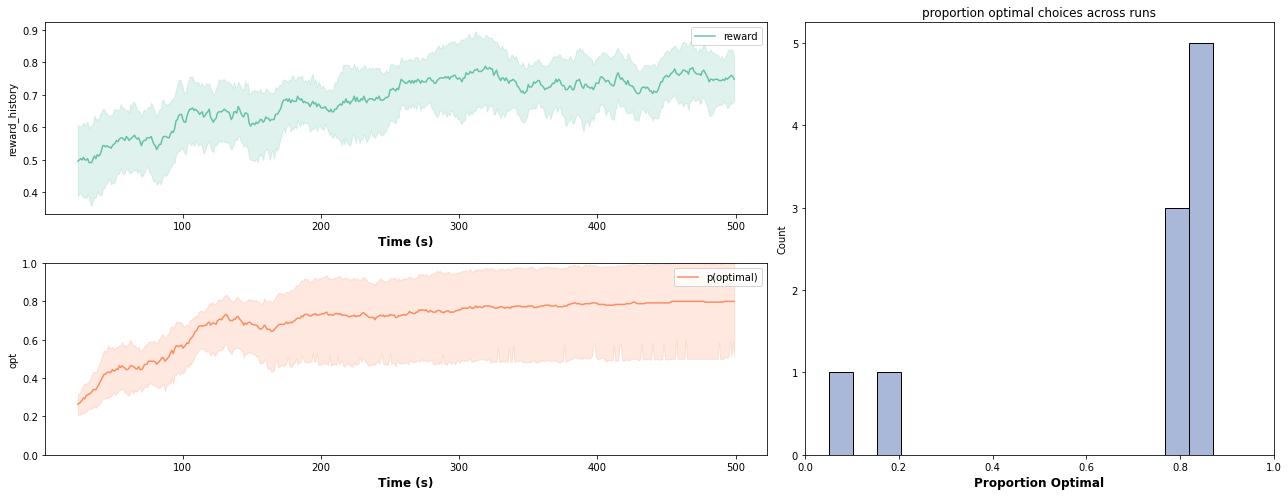

In [8]:
np.random.seed(100) # fix a seed for repeatable experiments

# parameters of simulation
n_timesteps = 500
n_runs = 10

# set up bandit options
n_bandits = 4
# bandit_means = [0,50,10,4]
# bandit_sds = [1]*n_bandits

reward_history_Fixed = []
opt_history_Fixed = []
run_history_Fixed = []
Q_history_Fixed = np.zeros((n_runs,n_timesteps,n_bandits))
timestep = []
action_mean_history_fixed=[]
for run in range(n_runs):  # repeat a given number random repetitions of the experiment
    action_means = []
    bandit = KBandit(n_bandits, stationary=True) # create a new bandit
    #agent = RandomAgent(n_bandits)
    #agent = AverageAgent(n_bandits)
    #agent = BernoulliThompsonAgent(n_bandits)
    agent = FixedAgent(n_bandits, lr=0.05)

  #  np.random.shuffle(bandit_means) # randomize location of "best"
    for i in range(n_timesteps): # for a certain number of time steps
        action = agent.choose() # let the agent choose
        reward, opt = bandit.step(action)
        agent.update(action, reward)
        
        Q_history_Fixed[run,i]=agent.q_values
        
        reward_history_Fixed.append(reward)
        opt_history_Fixed.append(opt)
        run_history_Fixed.append(run)
        timestep.append(i)
        action_means.append(bandit.action_values)
    action_mean_history_fixed.append(action_means)
# plot the results
sim_result_df=pd.DataFrame({"run": run_history_Fixed, "timepoint": timestep, "reward_history":reward_history_Fixed, "opt": opt_history_Fixed})
plot_results(sim_result_df)

Text(0.5, 0, 'Time(s)')

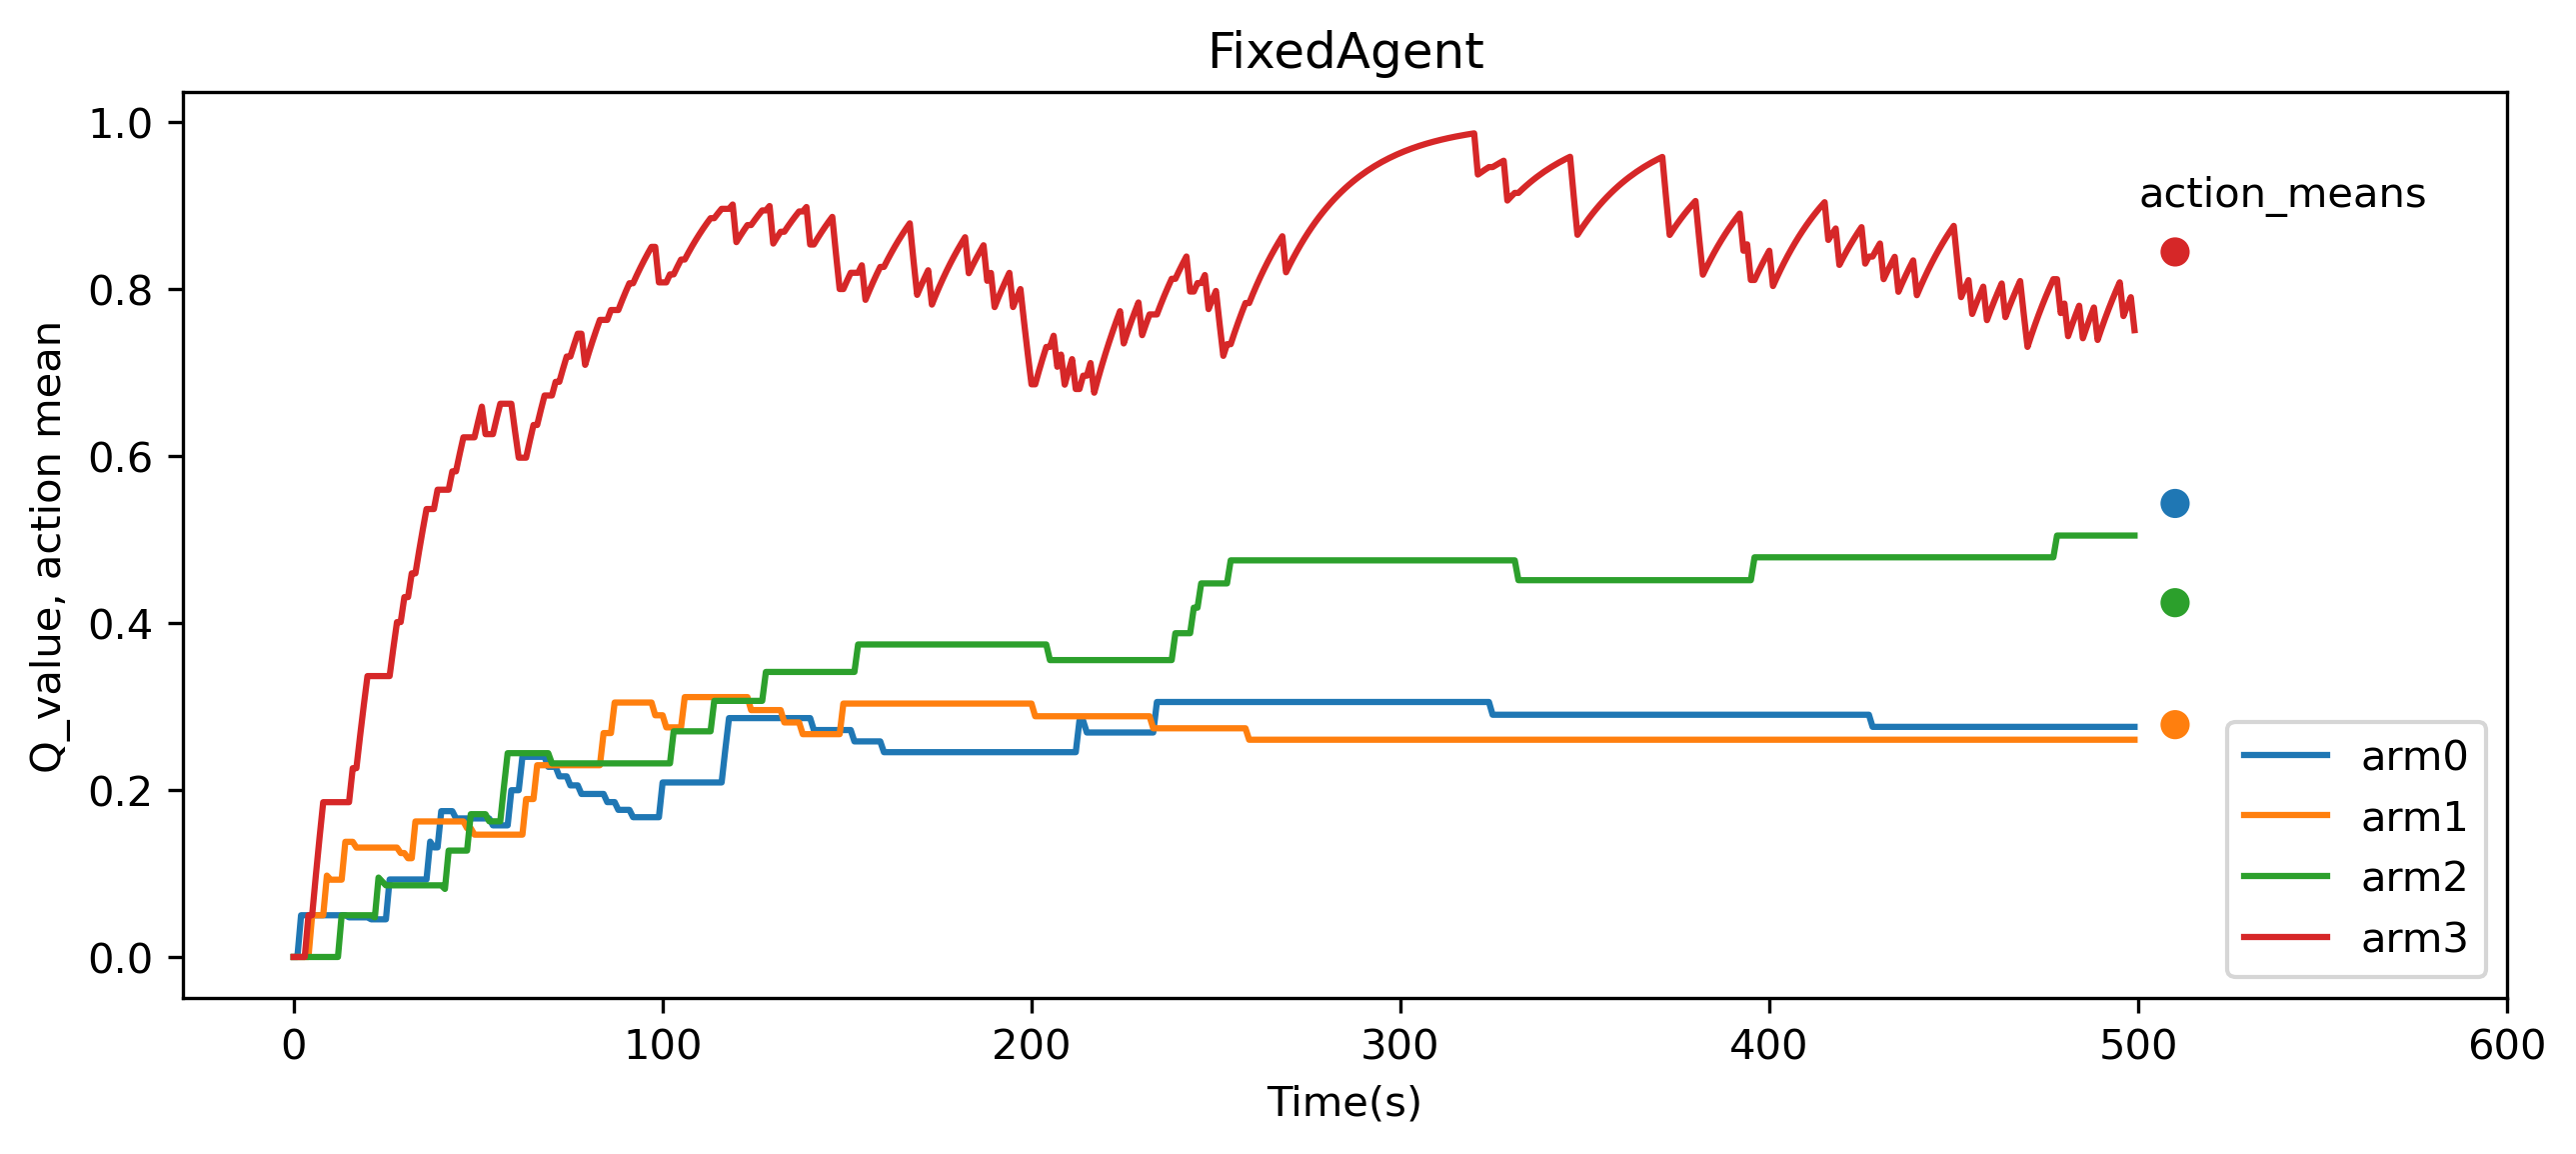

In [9]:
plt.figure(figsize=(10,4),dpi=300)

show_run=0

plt.plot(np.array(Q_history_Fixed[show_run]))
plt.scatter(np.zeros(n_bandits)+510,action_mean_history_fixed[show_run][0],c=['C0','C1','C2','C3'])#,'C4','C5','C6','C7','C8','C9'])
plt.text(500,0.9,'action_means')
plt.legend(['arm0','arm1','arm2','arm3'],loc='lower right') # ,'arm4','arm5','arm6','arm7','arm8','arm9'
plt.xlim(-30,600)
plt.title('FixedAgent')
plt.ylabel('Q_value, action mean')
plt.xlabel('Time(s)')

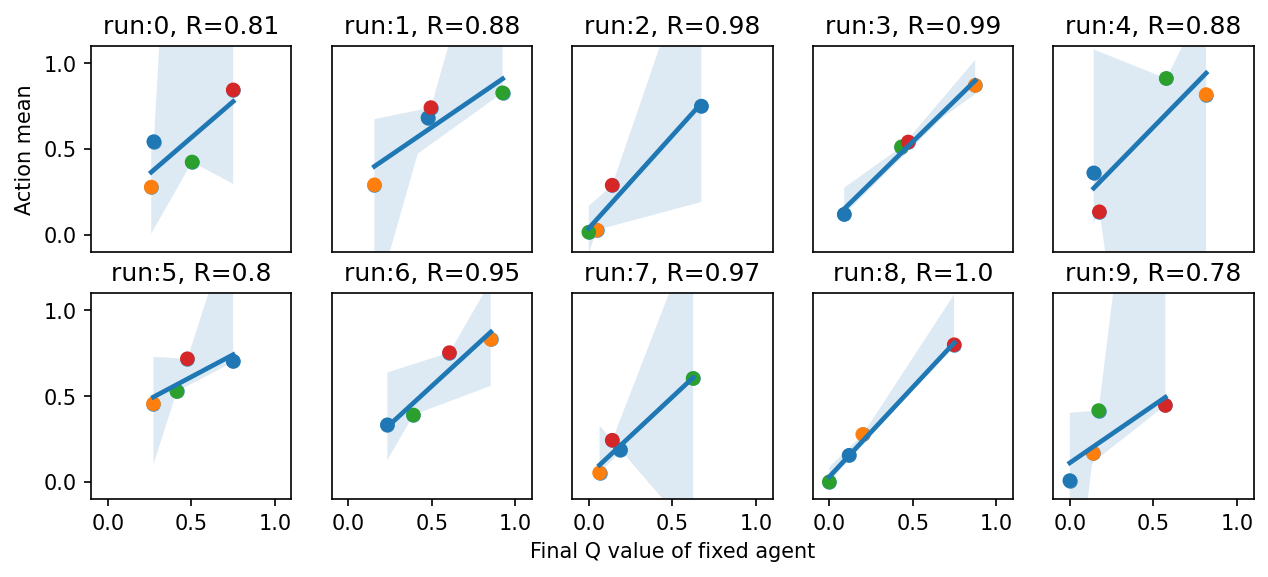

In [10]:
from scipy import stats
import seaborn as sns
plt.figure(figsize=(10,4),dpi=150)
for show_run in range(10):
    plt.subplot(2,5,show_run+1)
    sns.regplot(x=Q_history_Fixed[show_run,-1],y=action_mean_history_fixed[show_run][-1])
    plt.scatter(Q_history_Fixed[show_run,-1],action_mean_history_fixed[show_run][-1],c=['C0','C1','C2','C3'])#,'C4','C5','C6','C7','C8','C9'])
    plt.xlim(-0.1,1.1)
    plt.ylim(-0.1,1.1)
    if show_run%5!=0:
        plt.yticks([])
    if show_run<5:
        plt.xticks([])
    if show_run==0:
        plt.ylabel('Action mean')
    if show_run==7:
        plt.xlabel('Final Q value of fixed agent')
    plt.title('run:{}, R={}'.format(show_run,np.round(stats.pearsonr(Q_history_Fixed[show_run,-1],action_mean_history_fixed[show_run][-1])[0],2)))

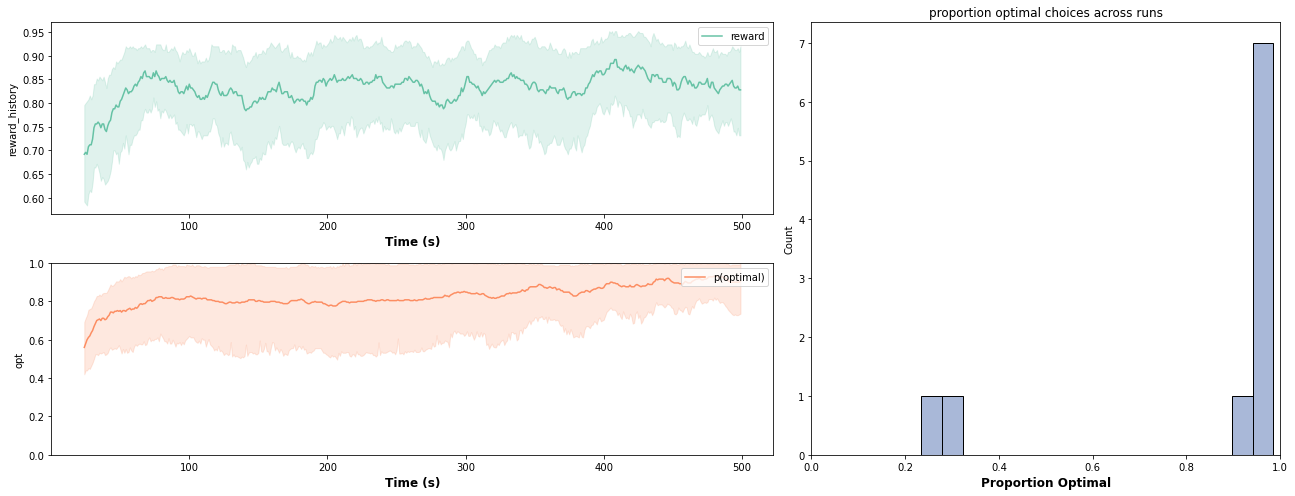

In [11]:
np.random.seed(100) 
n_timesteps = 500
n_runs = 10
n_bandits = 4
reward_history_bern = []
opt_history_bern = []
run_history_bern = []
Q_history_bern = np.zeros((n_runs,n_timesteps,n_bandits))
Q_var_history_bern = np.zeros((n_runs,n_timesteps,n_bandits))
timestep = []
action_mean_history_bern=[]
for run in range(n_runs):  # repeat a given number random repetitions of the experiment
    action_means = []
    bandit = KBandit(n_bandits, stationary=True) # create a new bandit
    agent = BernoulliThompsonAgent(n_bandits)
    
    for i in range(n_timesteps): # for a certain number of time steps
        action = agent.choose() # let the agent choose
        reward, opt = bandit.step(action)
        agent.update(action, reward)
        
        Q_history_bern[run,i]=agent.action_values
        Q_var_history_bern[run,i]=agent.action_var
        
        reward_history_bern.append(reward)
        opt_history_bern.append(opt)
        run_history_bern.append(run)
        timestep.append(i)
        action_means.append(bandit.action_values)
    action_mean_history_bern.append(action_means)
# plot the results
sim_result_df=pd.DataFrame({"run": run_history_bern, "timepoint": timestep, "reward_history":reward_history_bern, "opt": opt_history_bern})
plot_results(sim_result_df)

Text(0.5, 0, 'Time(s)')

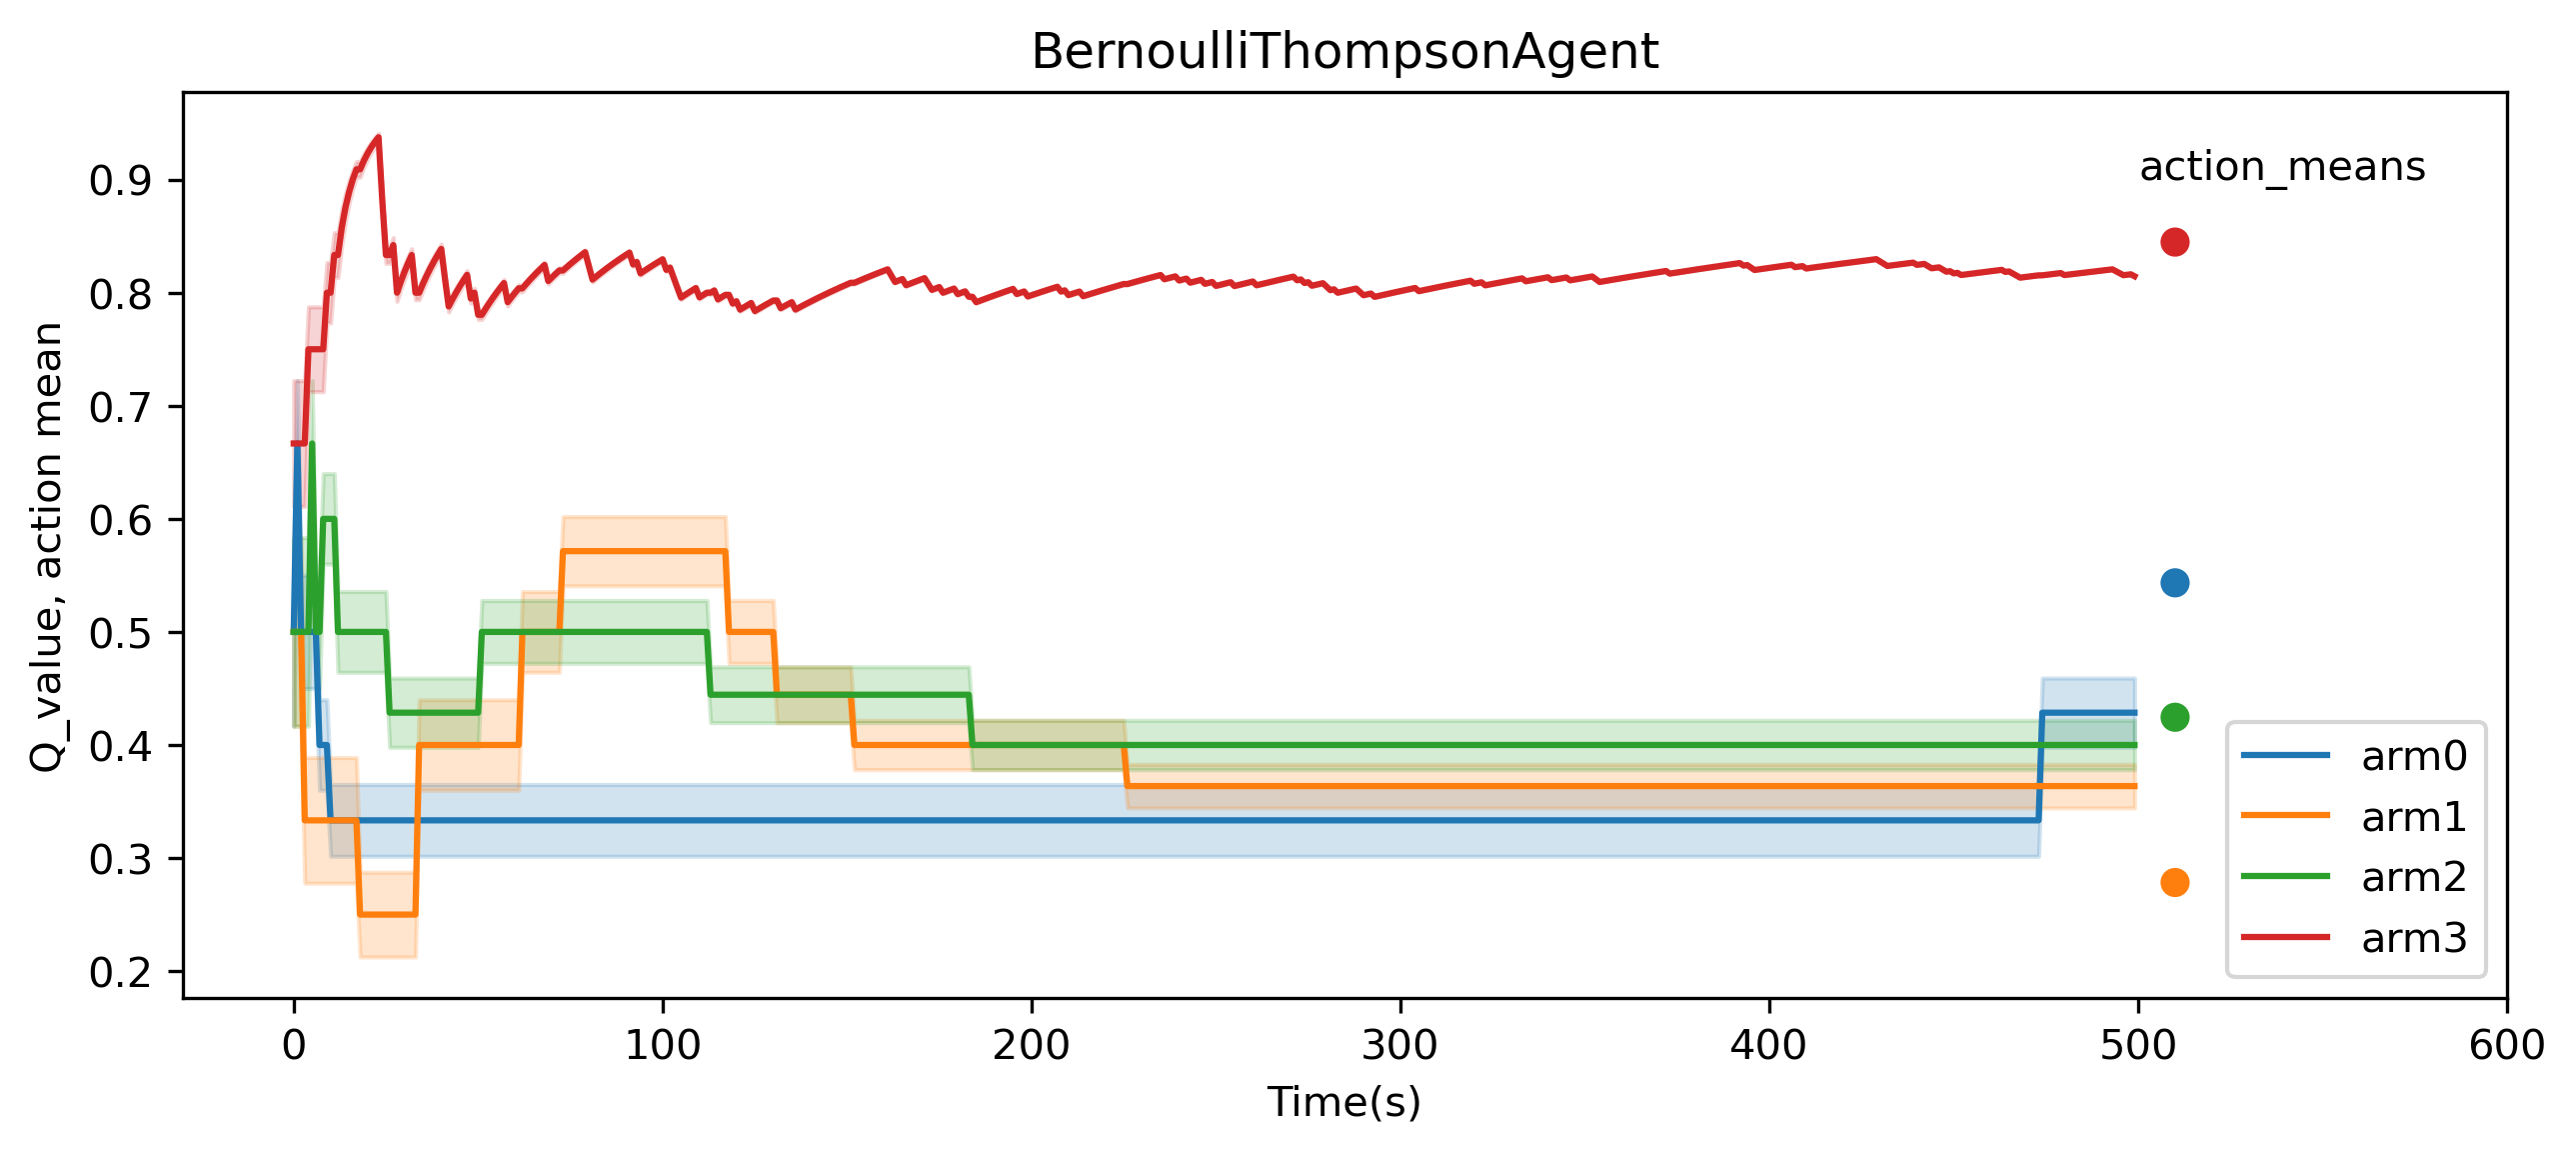

In [12]:
plt.figure(figsize=(10,4),dpi=300)
show_run=0
plt.plot(np.array(Q_history_bern[show_run]))
for arm in range(n_bandits):
    plt.fill_between(np.arange(500),Q_history_bern[show_run,:,arm]-Q_var_history_bern[show_run,:,arm],Q_history_bern[show_run,:,arm]+Q_var_history_bern[show_run,:,arm],
                     color='C'+str(arm),alpha=0.2)
plt.scatter(np.zeros(n_bandits)+510,action_mean_history_bern[show_run][0],c=['C0','C1','C2','C3'])#,'C4','C5','C6','C7','C8','C9'])
plt.text(500,0.9,'action_means')
plt.legend(['arm0','arm1','arm2','arm3'],loc='lower right')
plt.xlim(-30,600)
plt.title('BernoulliThompsonAgent')
plt.ylabel('Q_value, action mean')
plt.xlabel('Time(s)')

Text(0.5, 0, 'Time')

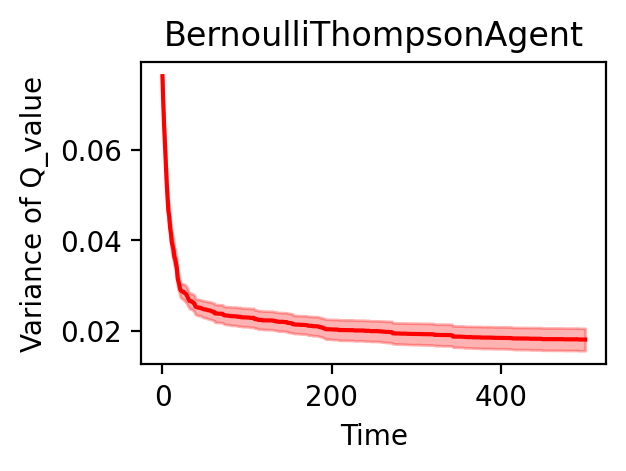

In [13]:
from scipy import stats
plt.figure(figsize=(3,2),dpi=200)
mean=np.mean(Q_var_history_bern,axis=(0,2))
var=stats.sem(np.mean(Q_var_history_bern,axis=2),axis=0)
plt.plot(mean,c='r')
plt.fill_between(np.arange(500),mean-var,mean+var,color='r',alpha=0.3)
plt.title('BernoulliThompsonAgent')
plt.ylabel('Variance of Q_value')
plt.xlabel('Time')

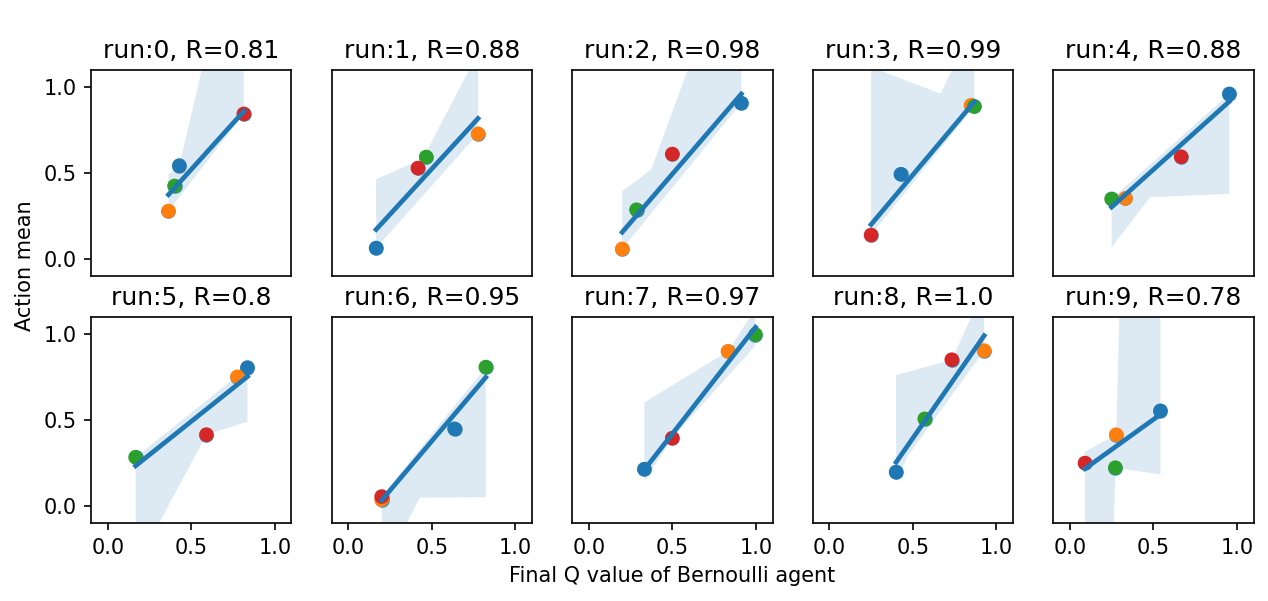

In [14]:
import seaborn as sns
plt.figure(figsize=(10,4),dpi=150)
for show_run in range(10):
    plt.subplot(2,5,show_run+1)
    sns.regplot(x=Q_history_bern[show_run,-1],y=action_mean_history_bern[show_run][-1])
    plt.scatter(Q_history_bern[show_run,-1],action_mean_history_bern[show_run][-1],c=['C0','C1','C2','C3'])
    plt.xlim(-0.1,1.1)
    plt.ylim(-0.1,1.1)
    if show_run%5!=0:
        plt.yticks([])
    if show_run<5:
        plt.xticks([])
    if show_run==0:
        plt.ylabel('Action mean                            ')
    if show_run==7:
        plt.xlabel('Final Q value of Bernoulli agent')
    plt.title('run:{}, R={}'.format(show_run,np.round(stats.pearsonr(Q_history_Fixed[show_run,-1],action_mean_history_fixed[show_run][-1])[0],2)))

Text(0.5, 0, 'time')

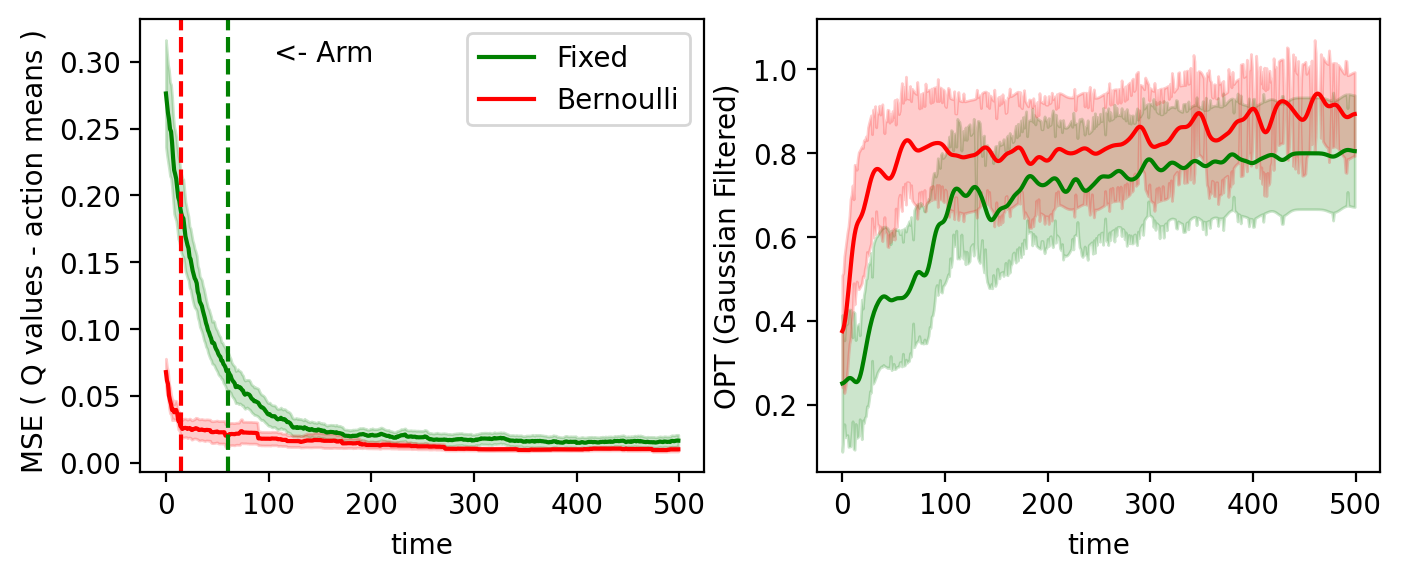

In [15]:
from scipy import stats
from scipy.ndimage import gaussian_filter1d
plt.figure(figsize=(8,3),dpi=200)
plt.subplot(1,2,1)
plt.xlabel('time')
MSE_Fixed_trend=np.mean(np.abs(Q_history_Fixed - np.array(action_mean_history_fixed))**2,axis=2)#np.zeros((10,500))
MSE_bern_trend=np.mean(np.abs(Q_history_bern - np.array(action_mean_history_bern))**2,axis=2)#np.zeros((10,500))

mean=np.mean(MSE_Fixed_trend,axis=0)
var=stats.sem(MSE_Fixed_trend,axis=0)
plt.plot(mean,c='g',label='Fixed')
plt.fill_between(np.arange(500),mean-var,mean+var,color='g',alpha=0.2)

mean=np.mean(MSE_bern_trend,axis=0)
var=stats.sem(MSE_bern_trend,axis=0)
plt.plot(mean,c='r',label='Bernoulli')
plt.fill_between(np.arange(500),mean-var,mean+var,color='r',alpha=0.2)
plt.legend()
plt.ylabel('MSE ( Q values - action means ) ')
plt.axvline(60,c='g',linestyle='--')
plt.axvline(15,c='r',linestyle='--')
plt.text(105,0.3,'<- Arm')

plt.subplot(1,2,2)
mean=gaussian_filter1d(np.mean(np.array(opt_history_Fixed).reshape(10,500),axis=0),5)
var=stats.sem(np.array(opt_history_Fixed).reshape(10,500),axis=0)
plt.plot(mean,c='g',label='Fixed')
plt.fill_between(np.arange(500),mean-var,mean+var,color='g',alpha=0.2)

mean=gaussian_filter1d(np.mean(np.array(opt_history_bern).reshape(10,500),axis=0),5)
var=stats.sem(np.array(opt_history_bern).reshape(10,500),axis=0)
plt.plot(mean,c='r',label='Bernoulli')
plt.fill_between(np.arange(500),mean-var,mean+var,color='r',alpha=0.2)
plt.ylabel('OPT (Gaussian Filtered)')
plt.xlabel('time')

In [16]:
np.random.seed(100) # fix a seed for repeatable experiments
n_timesteps = 500
n_runs = 10
n_bandits = 4

Q_history_Fixed_lr03 = np.zeros((n_runs,n_timesteps,n_bandits))
Q_history_Fixed_lr1 = np.zeros((n_runs,n_timesteps,n_bandits))
action_mean_history_fixed_lr03=[]
action_mean_history_fixed_lr1=[]
opt_history_Fixed_lr1=[]
opt_history_Fixed_lr03=[]
for run in range(n_runs):  # repeat a given number random repetitions of the experiment
    action_means = []
    bandit = KBandit(n_bandits, stationary=True) # create a new bandit
    agent_03 = FixedAgent(n_bandits, lr=0.3)
    agent_1 = FixedAgent(n_bandits, lr=1)

    for i in range(n_timesteps): # for a certain number of time steps
        action_03 = agent_03.choose() # let the agent choose
        action_1  = agent_1.choose() # let the agent choose
        reward_03, opt_03 = bandit.step(action_03)
        reward_1, opt_1 = bandit.step(action_1)
        agent_03.update(action_03, reward_03)
        agent_1.update(action_1, reward_1)
        Q_history_Fixed_lr03[run,i]=agent_03.q_values
        Q_history_Fixed_lr1[run,i]=agent_1.q_values
        
        opt_history_Fixed_lr03.append(opt_03)
        opt_history_Fixed_lr1.append(opt_1)
        
        action_means.append(bandit.action_values)
    action_mean_history_fixed_lr03.append(action_means)
    action_mean_history_fixed_lr1.append(action_means)

In [17]:
len(opt_history_Fixed_lr03)

5000

Text(0.5, 0, 'time')

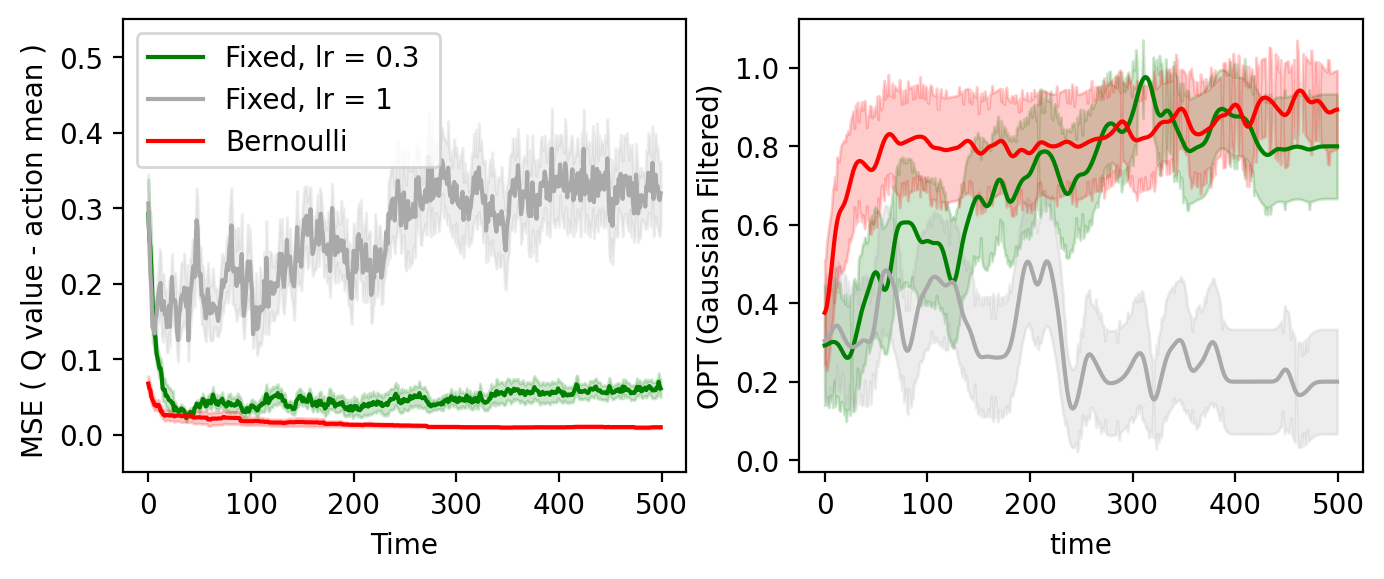

In [18]:
plt.figure(figsize=(8,3),dpi=200)
plt.subplot(1,2,1)
plt.ylim(-0.05,0.55)
MSE_Fixed_trend_03=np.mean(np.abs(Q_history_Fixed_lr03 - np.array(action_mean_history_fixed_lr03))**2,axis=2)#np.zeros((10,500))
MSE_Fixed_trend_1=np.mean(np.abs(Q_history_Fixed_lr1 - np.array(action_mean_history_fixed_lr1))**2,axis=2)#np.zeros((10,500))
MSE_bern_trend=np.mean(np.abs(Q_history_bern - np.array(action_mean_history_bern))**2,axis=2)#np.zeros((10,500))

mean=np.mean(MSE_Fixed_trend_03,axis=0)
var=stats.sem(MSE_Fixed_trend_03,axis=0)
plt.plot(mean,c='g',label='Fixed, lr = 0.3 ')
plt.fill_between(np.arange(500),mean-var,mean+var,color='g',alpha=0.2)

mean=np.mean(MSE_Fixed_trend_1,axis=0)
var=stats.sem(MSE_Fixed_trend_1,axis=0)
plt.plot(mean,c='darkgray',label='Fixed, lr = 1 ')
plt.fill_between(np.arange(500),mean-var,mean+var,color='darkgray',alpha=0.2)

mean=np.mean(MSE_bern_trend,axis=0)
var=stats.sem(MSE_bern_trend,axis=0)
plt.plot(mean,c='r',label='Bernoulli')
plt.fill_between(np.arange(500),mean-var,mean+var,color='r',alpha=0.2)
plt.legend()
plt.ylabel('MSE ( Q value - action mean ) ')
plt.xlabel('Time')

plt.subplot(1,2,2)
mean=gaussian_filter1d(np.mean(np.array(opt_history_Fixed_lr03).reshape(10,500),axis=0),5)
var=stats.sem(np.array(opt_history_Fixed_lr03).reshape(10,500),axis=0)
plt.plot(mean,c='g',label='Fixed')
plt.fill_between(np.arange(500),mean-var,mean+var,color='g',alpha=0.2)

mean=gaussian_filter1d(np.mean(np.array(opt_history_Fixed_lr1).reshape(10,500),axis=0),5)
var=stats.sem(np.array(opt_history_Fixed_lr1).reshape(10,500),axis=0)
plt.plot(mean,c='darkgray',label='Fixed')
plt.fill_between(np.arange(500),mean-var,mean+var,color='darkgray',alpha=0.2)

mean=gaussian_filter1d(np.mean(np.array(opt_history_bern).reshape(10,500),axis=0),5)
var=stats.sem(np.array(opt_history_bern).reshape(10,500),axis=0)
plt.plot(mean,c='r',label='Bernoulli')
plt.fill_between(np.arange(500),mean-var,mean+var,color='r',alpha=0.2)
plt.ylabel('OPT (Gaussian Filtered)')
plt.xlabel('time')

The experimental results indicate that the fixed agent effectively updated the Q-value of the optimal arm but struggled to learn the Q-values of the suboptimal arms. Additionally, the fixed agent selected the optimal arm less frequently compared to the Bernoulli agent. In contrast, the Bernoulli agent not only accurately learned the action means of the suboptimal arms but also exhibited faster learning and an effective convergence pattern in its Q-values. When the learning rate of the fixed agent was increased (it did not converge when lr > 0.5), the agent learned quickly but showed oscillation in its Q-values without reaching convergence. As a result, the Bernoulli agent proves to be more suitable in stationary conditions.

The epsilon-greedy exploration strategy is uninformed and inefficient since it selects random actions with probability ϵ, regardless of the estimated value of each action. As a result, the agent may continue exploring suboptimal actions even after gathering sufficient information about better alternatives, making convergence more difficult. Moreover, it fails to account for uncertainty in action-value estimates. In contrast, a Bernoulli-based approach (such as Thompson Sampling) selects actions based not only on their estimated value but also on their uncertainty. This means that even if an action has a low estimated value, it can still be chosen if its uncertainty is high, allowing the agent to continue refining its estimates. On the other hand, the Fixed Learning Rate Agent relies solely on random exploration via ϵ, making it less effective at learning about suboptimal actions that may still hold potential due to high uncertainty. Thompson Sampling efficiently learns by dynamically adjusting the exploration-exploitation balance based on uncertainty, which allows it to converge more quickly and stably. In contrast, 𝜖-greedy forces exploration with a fixed probability, making exploration inefficient and potentially taking longer to find the optimal arm.

## Q2
(1) Implement an agent using the Kalman filter to estimate a non-stationary value function of each arm for 500 trials. Assume that the agent knows the variance of the non-stationary drift of the mean payoffs from 4 arms (“state_noise” of “NArmBandit” class) and the variance of the sampled rewards from the 4 arms (“measurement_noise” of “NArmBandit” class). You can use any action policy (e.g., epsilon-greedy, softmax, and so on) for the agent.

In [19]:
class EpsilonSoftmaxAgent_kalman:
    def __init__(self, n_arms, epsilon=1, decay_factor=0.01, epsilon_min=0.01,init_U=1, state_noise=0.1, measurement_noise=0.1,policy='Epsilon'):
        self.n_arms = n_arms
        self.epsilon = epsilon
        self.decay_factor = decay_factor
        self.epsilon_min = epsilon_min
        self.q_values = np.zeros(n_arms)
        self.timestep = 0
        self.policy=policy
        self.state_noise=state_noise
        self.measurement_noise=measurement_noise
        self.uncertainties = np.ones(n_arms) * init_U
        self.K_gain=np.ones(n_arms)
    def choose(self):
        if self.policy=='Epsilon':
            if np.random.rand() < self.epsilon:
                 # Choose a random action
                action = np.random.randint(self.n_arms)
            else:
                # Choose the action with the highest Q-value
                action = np.argmax(self.q_values)
            self.epsilon = max(self.epsilon*self.decay_factor, self.epsilon_min)
        if self.policy=='Softmax':
            action = np.random.choice(self.n_arms, p=np.exp(self.q_values)/np.sum(np.exp(self.q_values)))   
        return action

    def update(self, action, reward):
        self.timestep += 1       
        #### Kalman Filter!!! ##################################################################
        prior_q = self.q_values[action]                                                        #
        prior_uncertainty = self.uncertainties[action] + self.state_noise                      # 
                                                                                               #
        self.K_gain[action] = prior_uncertainty / (prior_uncertainty + self.measurement_noise) #
                                                                                               # 
        self.q_values[action] = prior_q + self.K_gain[action] * (reward - prior_q)             #
        self.uncertainties[action] = (1 - self.K_gain[action]) * prior_uncertainty             #
        ########################################################################################
    def reset(self):
        self.q_values = np.zeros(n_arms)
        self.timestep = 0

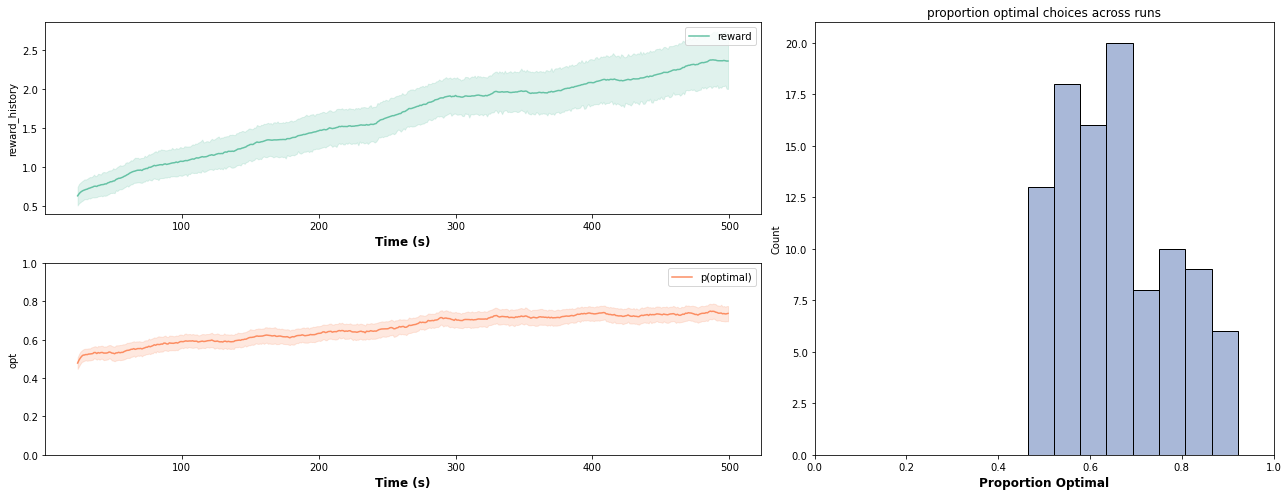

In [20]:
np.random.seed(100) # fix a seed for repeatable experiments
# parameters of simulation
n_timesteps = 500
n_runs = 100
n_bandits = 4

reward_history_Kalman = []
opt_history_Kalman_1 = []
run_history_Kalman = []
Q_history_Kalman = np.zeros((n_runs,n_timesteps,n_bandits))
Kgain_history_Kalman = np.zeros((n_runs,n_timesteps,n_bandits))
var_history_Kalman = np.zeros((n_runs,n_timesteps,n_bandits))
timestep = []
action_mean_history_Kalman=[]
for run in range(n_runs):  # repeat a given number random repetitions of the experiment
    action_means = []
    bandit = KBandit(n_bandits, stationary=False,reward_type='continuous', state_noise=0.1) # create a new bandit
    #agent = RandomAgent(n_bandits)
    #agent = AverageAgent(n_bandits)
    #agent = BernoulliThompsonAgent(n_bandits)
    agent = EpsilonSoftmaxAgent_kalman(n_bandits, state_noise=0.1, measurement_noise=0.1,policy='Softmax')
    
    for i in range(n_timesteps): # for a certain number of time steps
        action = agent.choose() # let the agent choose
        reward, opt = bandit.step(action)
        agent.update(action, reward)
        
        Q_history_Kalman[run,i]=agent.q_values
        Kgain_history_Kalman[run,i]=agent.K_gain
        var_history_Kalman[run,i]=agent.uncertainties
        
        reward_history_Kalman.append(reward)
        opt_history_Kalman_1.append(opt)
        run_history_Kalman.append(run)
        timestep.append(i)
        action_means.append(bandit.action_values.copy())
    action_mean_history_Kalman.append(action_means)
# plot the results
sim_result_df=pd.DataFrame({"run": run_history_Kalman, "timepoint": timestep, "reward_history":reward_history_Kalman, "opt": opt_history_Kalman_1})
plot_results(sim_result_df)

2) Plot time-varying estimated mean rewards with an overlay of the actual mean rewards. For 
the plots, you should show the estimated posterior variance from the Kalman filter using shaded 
error bars (estimated 𝑚𝑒𝑎𝑛 ± 𝑝𝑜𝑠𝑡𝑒𝑟𝑖𝑜𝑟	𝑣𝑎𝑟𝑖𝑎𝑛𝑐𝑒
 ). 

### Softmax

연한 실선은 actual mean reward를 나타내고 진한 실선은 agent의 Q value를 나타냄


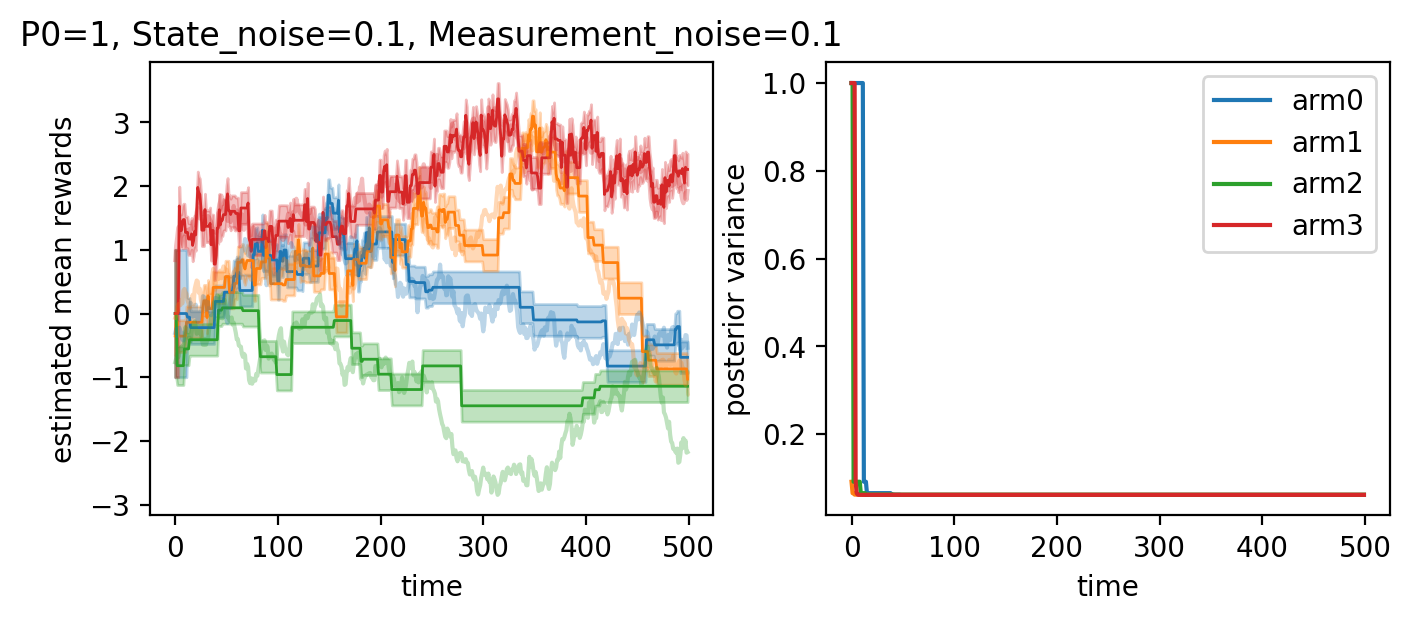

In [21]:
plt.figure(figsize=(8,3),dpi=200)
show_run=1
plt.subplot(1,2,1)
plt.plot(Q_history_Kalman[show_run],lw=1)
for i in range(4):
    plt.plot(np.array(action_mean_history_Kalman)[show_run,:,i],alpha=0.3,color='C'+str(i))
    plt.fill_between(np.arange(500),
                     Q_history_Kalman[show_run,:,i]-var_history_Kalman[show_run,:,i]**0.5,
                     Q_history_Kalman[show_run,:,i]+var_history_Kalman[show_run,:,i]**0.5, color='C'+str(i),alpha=0.3)
plt.title('P0=1, State_noise=0.1, Measurement_noise=0.1')
plt.ylabel('estimated mean rewards')
plt.xlabel('time')
plt.subplot(1,2,2)
plt.plot(var_history_Kalman[show_run])
plt.legend(['arm0','arm1','arm2','arm3'])
plt.ylabel('posterior variance')
plt.xlabel('time')
print('연한 실선은 actual mean reward를 나타내고 진한 실선은 agent의 Q value를 나타냄')

(3) Repeat (2) with different values of “state_noise” “measurement_noise” and discuss the 
results.  

In [22]:
np.random.seed(100) # fix a seed for repeatable experiments
n_agents=16
n_runs=100
Q_history_Kalman_Softmax = np.zeros((n_agents,n_runs,n_timesteps,n_bandits))
Kgain_history_Kalman_Softmax = np.zeros((n_agents,n_runs,n_timesteps,n_bandits))
var_history_Kalman_Softmax = np.zeros((n_agents,n_runs,n_timesteps,n_bandits))
opt_history_Kalman_Softmax = np.zeros((n_agents,n_runs,n_timesteps))
reward_history_Kalman_Softmax = np.zeros((n_agents,n_runs,n_timesteps))
action_mean_history_Kalman_Softmax=np.zeros((n_agents,n_runs,n_timesteps,n_bandits))
params=np.array([[0.001,0.001],[0.001,0.1],[0.01,1],[0.01,10],
        [0.1,0.01],[0.1,0.1],[0.1,1],[0.1,10],
        [1,0.01],[1,0.1],[1,1],[1,10],
        [10,0.01],[10,0.1],[10,1],[10,10]] )/2#state_noise,measurement_noise
for agent_idx in range(n_agents):
    for run in range(n_runs):  # repeat a given number random repetitions of the experiment
        bandit = KBandit(n_bandits, stationary=False,reward_type='continuous',state_noise=params[agent_idx][0]) # create a new bandit
        agent = EpsilonSoftmaxAgent_kalman(n_bandits,init_U=1,state_noise=params[agent_idx][0], measurement_noise=params[agent_idx][1],policy='Softmax')

        for i in range(n_timesteps): # for a certain number of time steps
            action = agent.choose() # let the agent choose
            reward, opt = bandit.step(action)
            
            agent.update(action, reward)

            opt_history_Kalman_Softmax[agent_idx,run,i]=opt
            Q_history_Kalman_Softmax[agent_idx,run,i]=agent.q_values
            Kgain_history_Kalman_Softmax[agent_idx,run,i]=agent.K_gain
            var_history_Kalman_Softmax[agent_idx,run,i]=agent.uncertainties        
            action_mean_history_Kalman_Softmax[agent_idx,run,i]=bandit.action_values.copy()
    


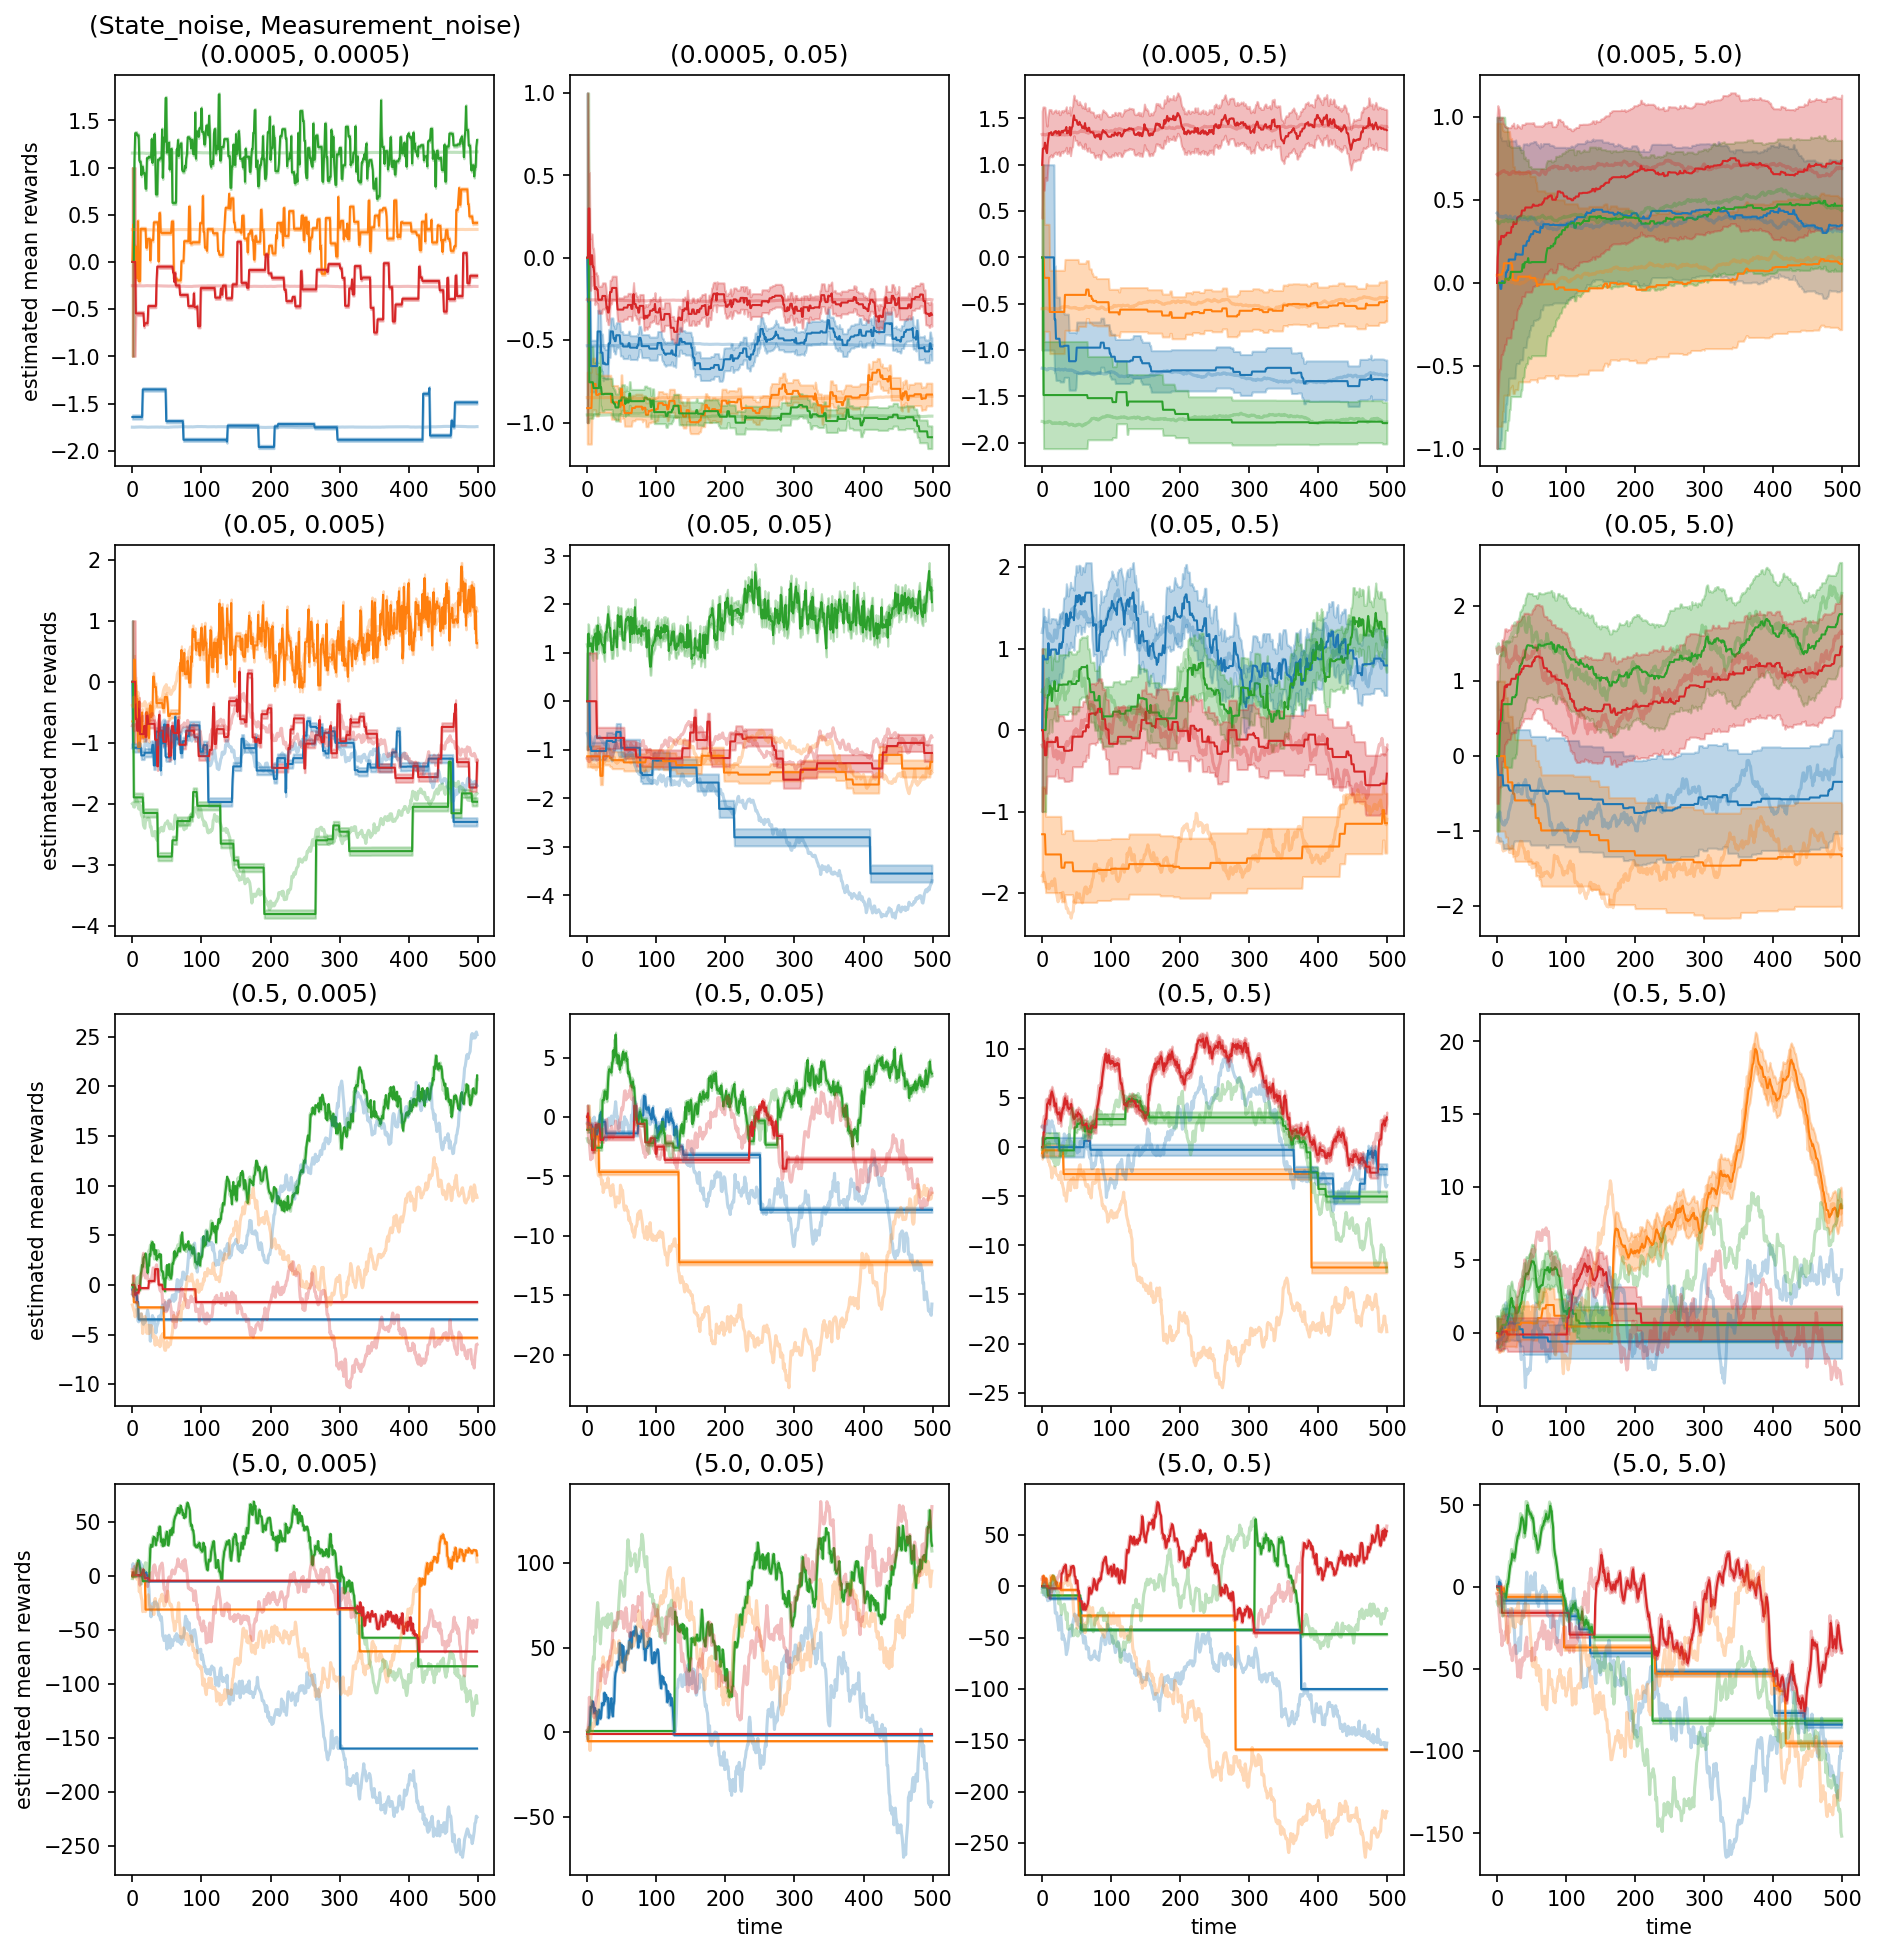

In [23]:
plt.figure(figsize=(15,15),dpi=150)
plt.subplots_adjust(bottom=0.1, right=0.9, top=0.9)
############## change run index
show_run=0
###############
for agent_idx in range(n_agents):
    plt.subplot(4,4,1+agent_idx)
    plt.plot(Q_history_Kalman_Softmax[agent_idx,show_run],lw=1)
    for i in range(4):
        plt.plot(np.array(action_mean_history_Kalman_Softmax)[agent_idx,show_run,:,i],alpha=0.3,color='C'+str(i))
        plt.fill_between(np.arange(500),
                         Q_history_Kalman_Softmax[agent_idx,show_run,:,i]-var_history_Kalman_Softmax[agent_idx,show_run,:,i]**0.5,
                         Q_history_Kalman_Softmax[agent_idx,show_run,:,i]+var_history_Kalman_Softmax[agent_idx,show_run,:,i]**0.5, color='C'+str(i),alpha=0.3)
    if agent_idx==0:
        plt.title('(State_noise, Measurement_noise)\n'+str(tuple(params[agent_idx])))
    else:
        plt.title(str(tuple(params[agent_idx])))
        
    if agent_idx%4==0:
        plt.ylabel('estimated mean rewards')
    if agent_idx>12:
        plt.xlabel('time')
    # plt.subplot(6,2,2+agent_idx*2)
    # plt.plot(var_history_Kalman_Softmax[agent_idx,show_run])
    # plt.legend(['arm0','arm1','arm2','arm3'])
    # plt.ylabel('posterior variance')
    # if agent_idx==5:
    #     plt.xlabel('time')

Text(0.5, 1.0, 'OPT(Softmax), 100 trials')

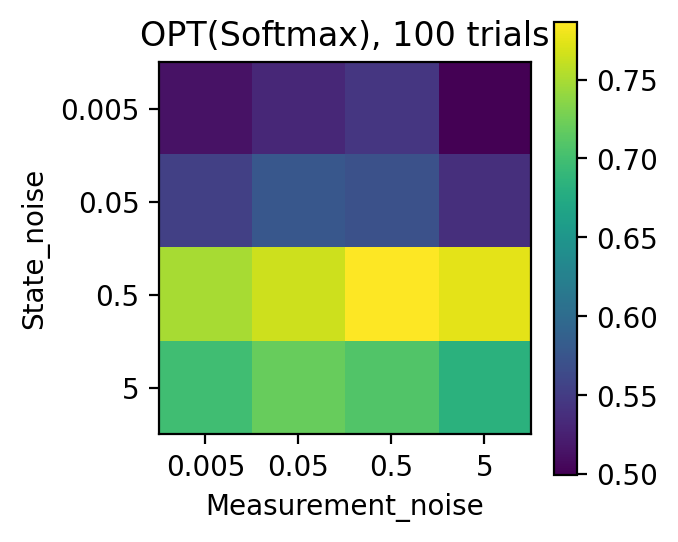

In [24]:
plt.figure(figsize=(3,3),dpi=200)
plt.imshow(np.mean(opt_history_Kalman_Softmax,axis=(1,2)).reshape(4,4))    
plt.colorbar()
plt.xticks([0,1,2,3],[0.005,0.05,0.5,5])
plt.yticks([0,1,2,3],[0.005,0.05,0.5,5])
plt.ylabel('State_noise')
plt.xlabel('Measurement_noise') 
plt.title('OPT(Softmax), 100 trials')

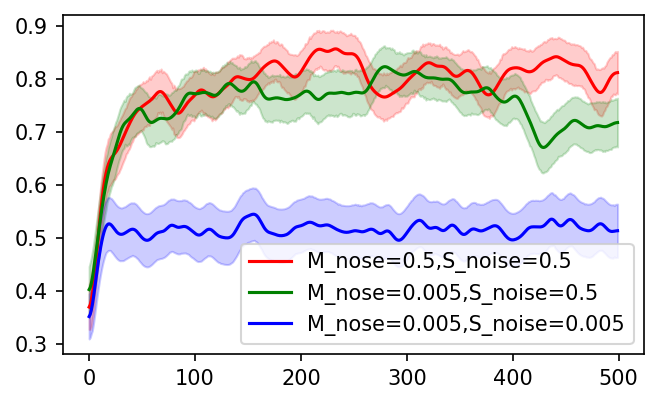

In [25]:
plt.figure(figsize=(5,3),dpi=150)
colors=['r','y','g','b','gray','tan']
mean,var=gaussian_filter1d(np.mean(opt_history_Kalman_Softmax[10],axis=0),5),stats.sem(opt_history_Kalman_Softmax[10],axis=0)
plt.plot(mean,c='r',label='M_nose=0.5,S_noise=0.5')
plt.fill_between(np.arange(500),mean-var,mean+var,color='r',alpha=0.2)

mean,var=gaussian_filter1d(np.mean(opt_history_Kalman_Softmax[8],axis=0),5),stats.sem(opt_history_Kalman_Softmax[8],axis=0)
plt.plot(mean,c='g',label='M_nose=0.005,S_noise=0.5')
plt.fill_between(np.arange(500),mean-var,mean+var,color='g',alpha=0.2)

mean,var=gaussian_filter1d(np.mean(opt_history_Kalman_Softmax[0],axis=0),5),stats.sem(opt_history_Kalman_Softmax[0],axis=0)
plt.plot(mean,c='b',label='M_nose=0.005,S_noise=0.005')
plt.fill_between(np.arange(500),mean-var,mean+var,color='b',alpha=0.2)
plt.legend()

In [26]:
np.random.seed(100) # fix a seed for repeatable experiments
n_agents=16
Q_history_Kalman_epsilon = np.zeros((n_agents,n_runs,n_timesteps,n_bandits))
Kgain_history_Kalman_epsilon = np.zeros((n_agents,n_runs,n_timesteps,n_bandits))
var_history_Kalman_epsilon = np.zeros((n_agents,n_runs,n_timesteps,n_bandits))
opt_history_Kalman_epsilon = np.zeros((n_agents,n_runs,n_timesteps))
reward_history_Kalman_epsilon = np.zeros((n_agents,n_runs,n_timesteps))
action_mean_history_Kalman_epsilon=np.zeros((n_agents,n_runs,n_timesteps,n_bandits))
params=np.array([[0.001,0.001],[0.001,0.1],[0.01,1],[0.01,10],
        [0.1,0.01],[0.1,0.1],[0.1,1],[0.1,10],
        [1,0.01],[1,0.1],[1,1],[1,10],
        [10,0.01],[10,0.1],[10,1],[10,10]] )/2#state_noise,measurement_noise
for agent_idx in range(n_agents):
    for run in range(n_runs):  # repeat a given number random repetitions of the experiment
        bandit = KBandit(n_bandits, stationary=False,reward_type='continuous',state_noise=params[agent_idx][0]) # create a new bandit
        agent = EpsilonSoftmaxAgent_kalman(n_bandits,init_U=1,state_noise=params[agent_idx][0], measurement_noise=params[agent_idx][1],policy='Epsilon')

        for i in range(n_timesteps): # for a certain number of time steps
            action = agent.choose() # let the agent choose
            reward, opt = bandit.step(action)
            
            agent.update(action, reward)

            opt_history_Kalman_epsilon[agent_idx,run,i]=opt
            Q_history_Kalman_epsilon[agent_idx,run,i]=agent.q_values
            Kgain_history_Kalman_epsilon[agent_idx,run,i]=agent.K_gain
            var_history_Kalman_epsilon[agent_idx,run,i]=agent.uncertainties        
            action_mean_history_Kalman_epsilon[agent_idx,run,i]=bandit.action_values.copy()
    


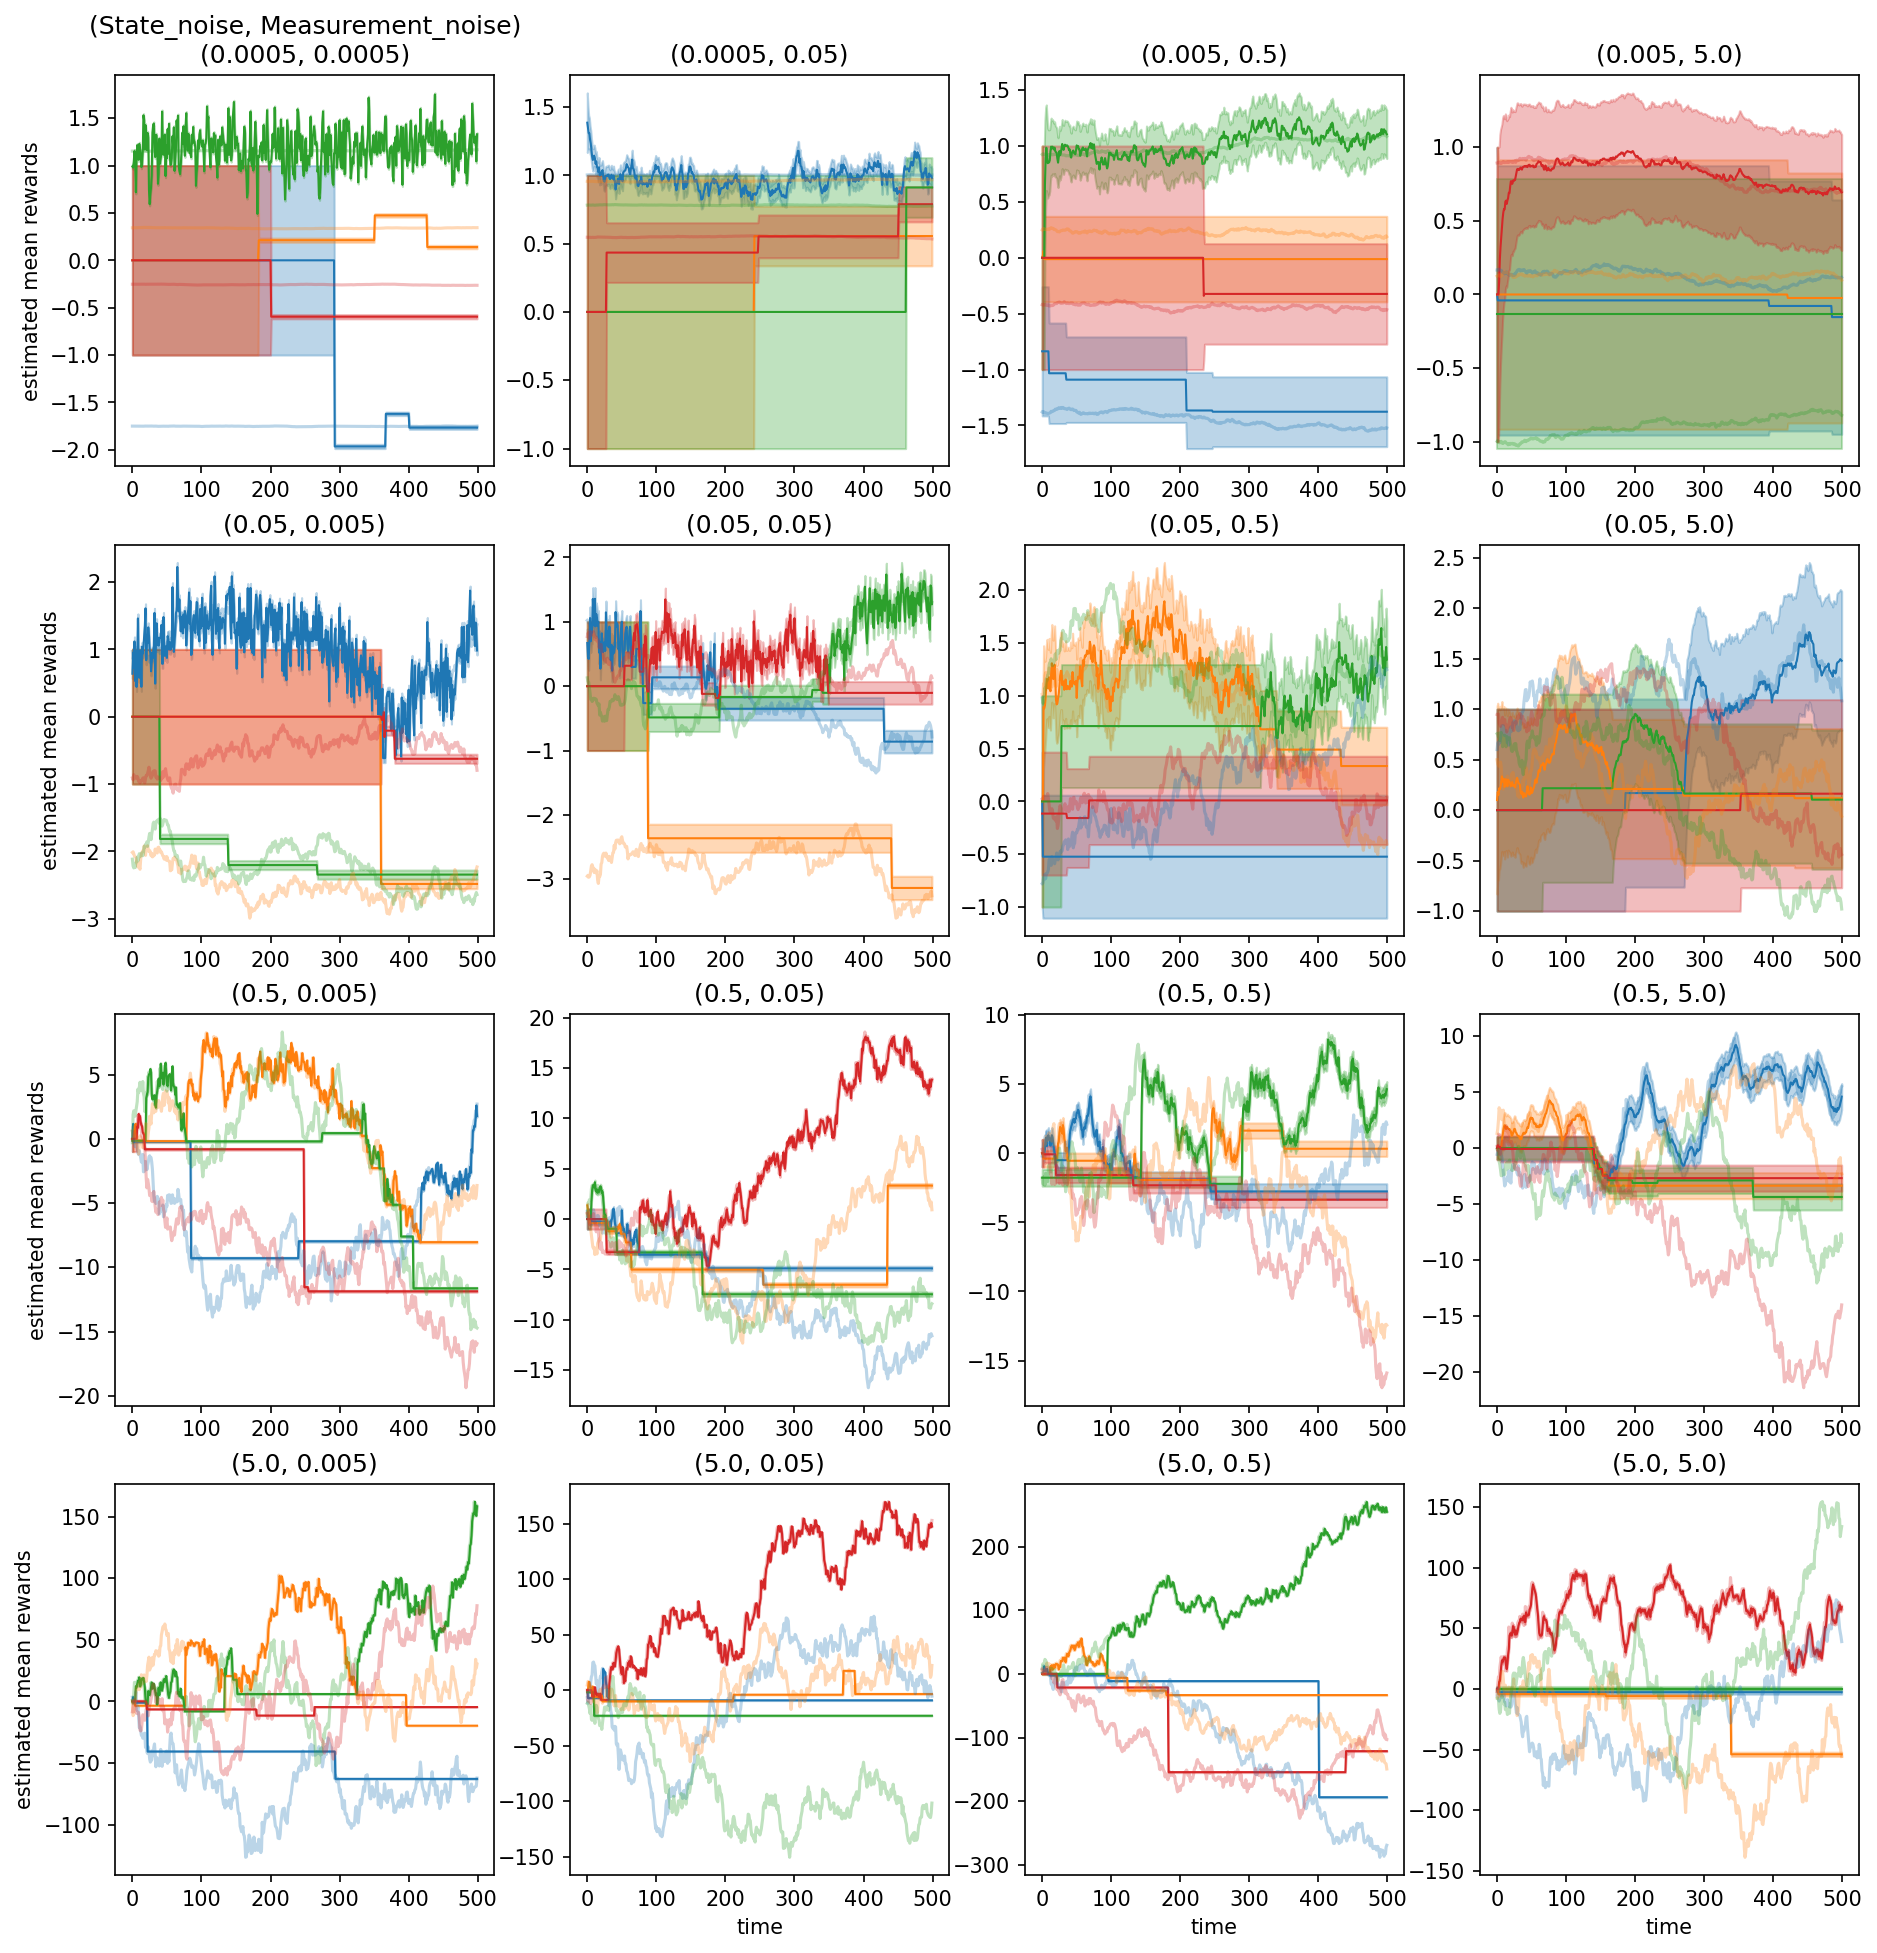

In [27]:
plt.figure(figsize=(15,15),dpi=150)
plt.subplots_adjust(bottom=0.1, right=0.9, top=0.9)
############## change run index
show_run=0
###############
for agent_idx in range(n_agents):
    plt.subplot(4,4,1+agent_idx)
    plt.plot(Q_history_Kalman_epsilon[agent_idx,show_run],lw=1)
    for i in range(4):
        plt.plot(np.array(action_mean_history_Kalman_epsilon)[agent_idx,show_run,:,i],alpha=0.3,color='C'+str(i))
        plt.fill_between(np.arange(500),
                         Q_history_Kalman_epsilon[agent_idx,show_run,:,i]-var_history_Kalman_epsilon[agent_idx,show_run,:,i]**0.5,
                         Q_history_Kalman_epsilon[agent_idx,show_run,:,i]+var_history_Kalman_epsilon[agent_idx,show_run,:,i]**0.5, color='C'+str(i),alpha=0.3)
    if agent_idx==0:
        plt.title('(State_noise, Measurement_noise)\n'+str(tuple(params[agent_idx])))
    else:
        plt.title(str(tuple(params[agent_idx])))
        
    if agent_idx%4==0:
        plt.ylabel('estimated mean rewards')
    if agent_idx>12:
        plt.xlabel('time')
    # plt.subplot(6,2,2+agent_idx*2)
    # plt.plot(var_history_Kalman_Softmax[agent_idx,show_run])
    # plt.legend(['arm0','arm1','arm2','arm3'])
    # plt.ylabel('posterior variance')
    # if agent_idx==5:
    #     plt.xlabel('time')

Text(0.5, 1.0, 'OPT(Epsilon), 100 trials')

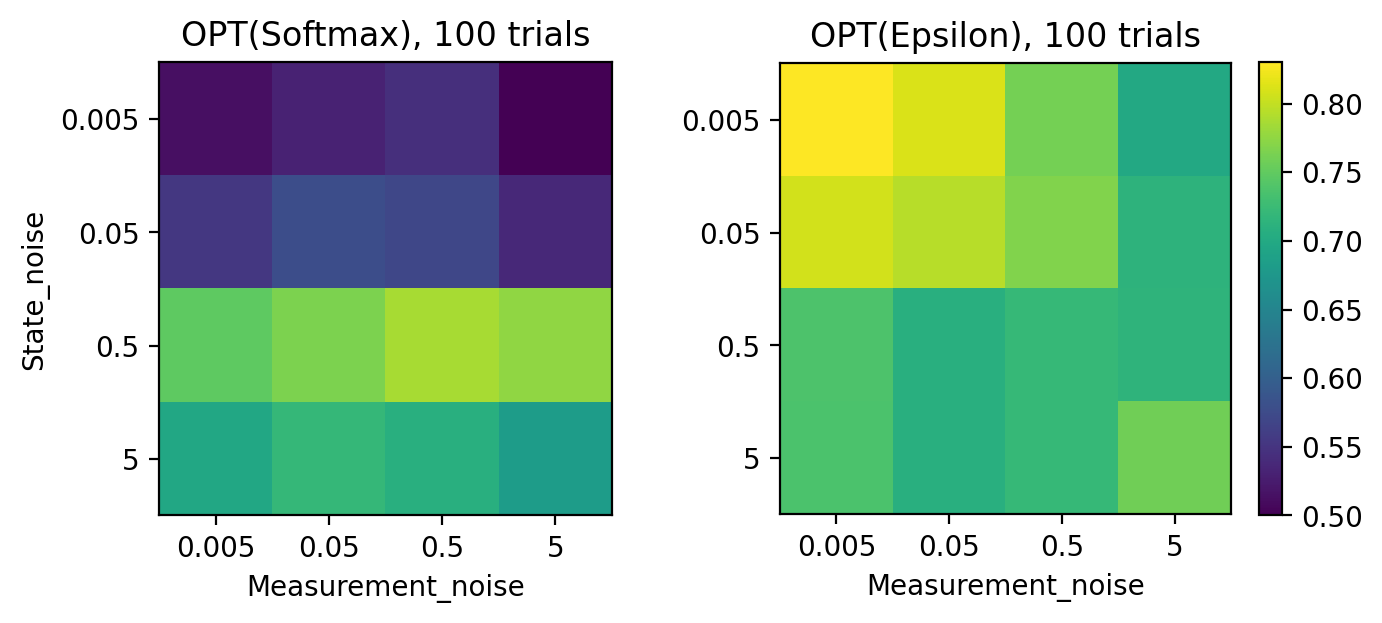

In [28]:
plt.figure(figsize=(8,3),dpi=200)
plt.subplot(1,2,1)
plt.imshow(np.mean(opt_history_Kalman_Softmax,axis=(1,2)).reshape(4,4),vmin=0.5,vmax=0.83)    
plt.xticks([0,1,2,3],[0.005,0.05,0.5,5])
plt.yticks([0,1,2,3],[0.005,0.05,0.5,5])
plt.ylabel('State_noise')
plt.xlabel('Measurement_noise') 
plt.title('OPT(Softmax), 100 trials')

plt.subplot(1,2,2)
plt.imshow(np.mean(opt_history_Kalman_epsilon,axis=(1,2)).reshape(4,4),vmin=0.5,vmax=0.83)    
plt.colorbar()
plt.xlabel('Measurement_noise') 
plt.xticks([0,1,2,3],[0.005,0.05,0.5,5])
plt.yticks([0,1,2,3],[0.005,0.05,0.5,5])
plt.title('OPT(Epsilon), 100 trials')

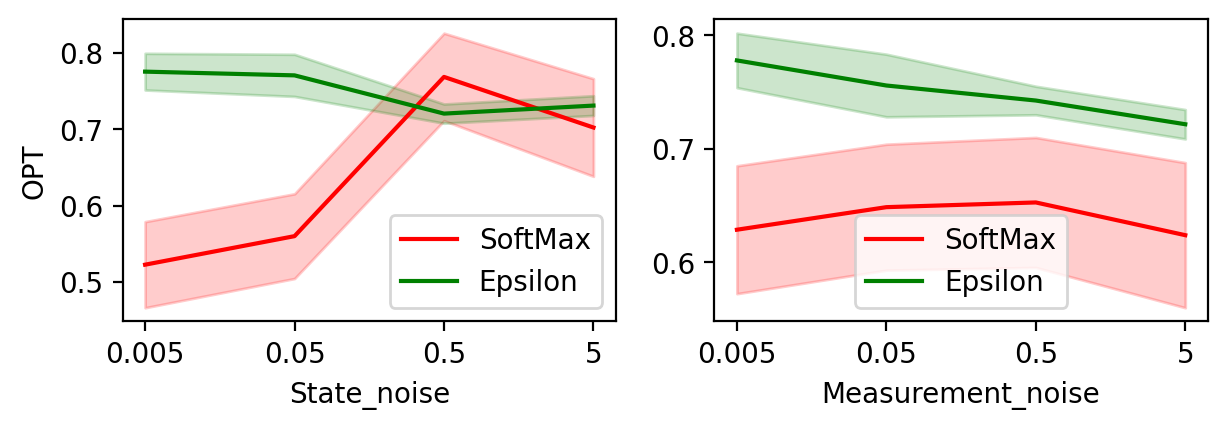

In [29]:
plt.figure(figsize=(7,2),dpi=200)
plt.subplot(1,2,1)
plt.ylabel('OPT')
plt.xlabel('State_noise') 
plt.xticks([0,1,2,3],[0.005,0.05,0.5,5])
mean=np.mean(opt_history_Kalman_Softmax.reshape(4,4,100,500),axis=(1,2,3))
var=stats.sem(np.mean(opt_history_Kalman_Softmax.reshape(4,4,100,500),axis=(2,3)),axis=0)
plt.plot(mean,c='r',label='SoftMax')
plt.fill_between(np.arange(4),mean-var,mean+var,color='r',alpha=0.2)

mean=np.mean(opt_history_Kalman_epsilon.reshape(4,4,100,500),axis=(1,2,3))
var=stats.sem(np.mean(opt_history_Kalman_epsilon.reshape(4,4,100,500),axis=(2,3)),axis=0)
plt.plot(mean,c='g',label='Epsilon')
plt.fill_between(np.arange(4),mean-var,mean+var,color='g',alpha=0.2)
plt.legend()

plt.subplot(1,2,2)
plt.xlabel('Measurement_noise') 
plt.xticks([0,1,2,3],[0.005,0.05,0.5,5])
mean=np.mean(opt_history_Kalman_Softmax.reshape(4,4,100,500),axis=(0,2,3))
var=stats.sem(np.mean(opt_history_Kalman_Softmax.reshape(4,4,100,500),axis=(2,3)),axis=0)
plt.plot(mean,c='r',label='SoftMax')
plt.fill_between(np.arange(4),mean-var,mean+var,color='r',alpha=0.2)

mean=np.mean(opt_history_Kalman_epsilon.reshape(4,4,100,500),axis=(0,2,3))
var=stats.sem(np.mean(opt_history_Kalman_epsilon.reshape(4,4,100,500),axis=(2,3)),axis=0)
plt.plot(mean,c='g',label='Epsilon')
plt.fill_between(np.arange(4),mean-var,mean+var,color='g',alpha=0.2)
plt.legend()

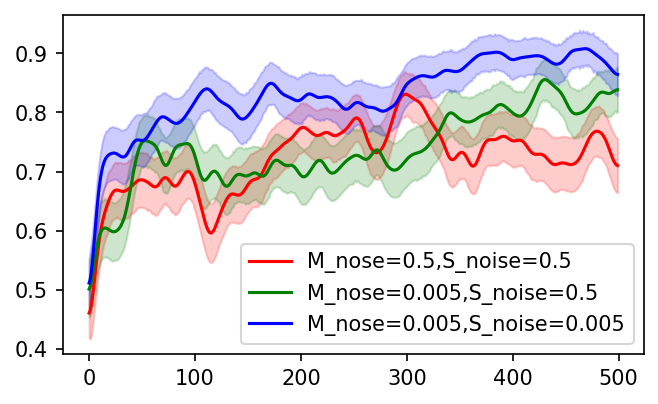

In [30]:
plt.figure(figsize=(5,3),dpi=150)
colors=['r','y','g','b','gray','tan']
mean,var=gaussian_filter1d(np.mean(opt_history_Kalman_epsilon[10],axis=0),5),stats.sem(opt_history_Kalman_epsilon[10],axis=0)
plt.plot(mean,c='r',label='M_nose=0.5,S_noise=0.5')
plt.fill_between(np.arange(500),mean-var,mean+var,color='r',alpha=0.2)

mean,var=gaussian_filter1d(np.mean(opt_history_Kalman_epsilon[8],axis=0),5),stats.sem(opt_history_Kalman_epsilon[8],axis=0)
plt.plot(mean,c='g',label='M_nose=0.005,S_noise=0.5')
plt.fill_between(np.arange(500),mean-var,mean+var,color='g',alpha=0.2)

mean,var=gaussian_filter1d(np.mean(opt_history_Kalman_epsilon[0],axis=0),5),stats.sem(opt_history_Kalman_epsilon[0],axis=0)
plt.plot(mean,c='b',label='M_nose=0.005,S_noise=0.005')
plt.fill_between(np.arange(500),mean-var,mean+var,color='b',alpha=0.2)
plt.legend()

- State noise

The modeling results showed that when state noise is small, the Epsilon-Greedy policy outperforms Softmax. This is because a small state noise indicates that the environment is almost stationary, meaning that the most efficient strategy is to quickly identify and consistently select the optimal arm.  

In the case of Epsilon-Greedy, once the optimal arm is found, it is chosen most of the time, except for occasional exploration with probability ε. This makes it highly efficient in a low state noise environment. On the other hand, Softmax determines action selection probabilities based on Q-value differences, meaning that the probability of selecting the optimal arm never reaches 100%. The agent continues to select suboptimal arms even after identifying the optimal arm, leading to unnecessary exploration. Due to this exploration behavior, Softmax may suffer from performance degradation in environments with low state noise. Therefore, in a low state noise environment, Epsilon-Greedy provides more stable performance.  

Additionally, Softmax does not rapidly decrease the probability of selecting suboptimal arms over time. This allows it to perform effective exploration when the state changes, making it more suitable for environments with high state noise. In contrast, Epsilon-Greedy significantly reduces the probability of selecting suboptimal arms over time, making it less adaptable to environments where the state frequently changes. However, even Softmax has limitations when state noise is too high, as it becomes difficult to accurately estimate the optimal arm. As a result, the performance of Softmax peaks at a certain level of state noise (e.g., state_noise = 0.5 in the given example).

The relationship between measurement noise and the two policies, Epsilon-Greedy and Softmax, plays a crucial role in determining their effectiveness in reinforcement learning tasks. Measurement noise affects the reliability of observed rewards, which in turn influences how each policy updates its value estimates and selects actions. If measurement noise is too high, both policies suffer, as learning becomes difficult due to unreliable observations. If measurement noise is too low, Epsilon-Greedy is more effective, because Softmax continues exploration even when unnecessary.

- Epsilon-Greedy and Measurement Noise

Epsilon-Greedy operates by selecting the arm with the highest estimated Q-value most of the time while occasionally exploring other options with probability ε. When measurement noise is high, observed rewards may deviate significantly from the true reward values, making it difficult for the agent to accurately estimate the Q-values. As a result, Epsilon-Greedy may take longer to identify the optimal arm and is more likely to settle on a suboptimal choice due to incorrect updates.
Conversely, when measurement noise is low, observed rewards closely reflect the true rewards, allowing Epsilon-Greedy to quickly find and exploit the optimal arm. In such conditions, Epsilon-Greedy performs better in low measurement noise environments, as it quickly identifies the optimal arm and minimizes unnecessary exploration..

- Softmax and Measurement Noise

Softmax selects actions probabilistically based on the differences in Q-values, meaning that even if an arm has the highest estimated value, it is not always chosen. This probabilistic nature allows Softmax to maintain exploration even when Q-values are uncertain. In high measurement noise environments, this property can prevent the agent from becoming overly confident in incorrect value estimates and help maintain exploration for better decision-making. However, if measurement noise is too high, the agent may struggle to learn meaningful differences between arms, leading to inefficient learning.
When measurement noise is low, Softmax can estimate Q-values more accurately, improving the selection of the optimal arm. However, unlike Epsilon-Greedy, Softmax never completely eliminates exploration. This means that even in stable environments with low measurement noise, Softmax may still choose suboptimal arms occasionally, leading to a slight performance loss compared to Epsilon-Greedy. Therefore, Softmax is more robust in environments with moderate measurement noise, as it maintains exploration and avoids overconfidence in incorrect estimates.
